In [ ]:
# ================================
# 1. SETUP (run once)
# ================================
import sys

# Install required packages
!{sys.executable} -m pip install -q textblob nltk spacy scikit-learn seaborn

# Download NLP resources
!{sys.executable} -m textblob.download_corpora
!{sys.executable} -m spacy download en_core_web_sm

import nltk
nltk.download('punkt')
nltk.download('stopwords')


# ================================
# 2. REPRODUCIBILITY
# ================================
import os
import random
import numpy as np

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

try:
    import torch
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
except ImportError:
    pass


# ================================
# 3. CORE LIBRARIES
# ================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split


# ================================
# 4. LOAD DATA
# ================================
df = pd.read_csv("ai_human_content_detection_dataset.csv")


# ================================
# 5. BASIC DATA UNDERSTANDING
# ================================
print("Shape:", df.shape)
print("\nClass distribution:")
print(df["label"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

if "content_type" in df.columns:
    print("\nContent types:")
    print(df["content_type"].unique())


# ================================
# 6. DESCRIPTIVE STATISTICS
# ================================
feature_cols = [
    'word_count', 'character_count', 'sentence_count', 'lexical_diversity',
    'avg_sentence_length', 'avg_word_length', 'punctuation_ratio',
    'flesch_reading_ease', 'gunning_fog_index', 'grammar_errors',
    'passive_voice_ratio', 'predictability_score', 'burstiness',
    'sentiment_score'
]

print("\nSummary statistics:")
display(df[feature_cols].describe())


# ================================
# 7. MISSING VALUE IMPUTATION
# ================================
print("\nMissing values BEFORE:")
print(df[feature_cols].isnull().sum())

# Mean imputation (clean + consistent)
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].mean())

print("\nMissing values AFTER:")
print(df[feature_cols].isnull().sum())


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
[nltk_data] Error loading brown: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading averaged_perceptron_tagger: <urlopen error
[nltk_data]     [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify
[nltk_data]     failed: unable to get local issuer certificate
[nltk_data]     (_ssl.c:1000)>
[nltk_data] Error loading conll2000: <urlopen error [SSL:
[nltk_data]     

[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>


Shape: (1367, 17)

Class distribution:
label
0    684
1    683
Name: count, dtype: int64

Missing values:
text_content             0
content_type             0
word_count               0
character_count          0
sentence_count           0
lexical_diversity        0
avg_sentence_length      0
avg_word_length          0
punctuation_ratio        0
flesch_reading_ease     79
gunning_fog_index       35
grammar_errors           0
passive_voice_ratio     31
predictability_score     0
burstiness               0
sentiment_score         54
label                    0
dtype: int64

Duplicate rows: 0

Content types:
['academic_paper' 'essay' 'creative_writing' 'news_article' 'blog_post'
 'article' 'social_media' 'product_review']

Summary statistics:


,word_count,character_count,sentence_count,lexical_diversity,avg_sentence_length,avg_word_length,punctuation_ratio,flesch_reading_ease,gunning_fog_index,grammar_errors,passive_voice_ratio,predictability_score,burstiness,sentiment_score
count,1367.000000,1367.000000,1367.000000,1367.000000,1367.000000,1367.000000,1367.000000,1288.000000,1332.000000,1367.000000,1336.000000,1367.000000,1367.000000,1313.000000
mean,140.190929,940.329188,25.610095,0.967646,5.486423,5.717783,0.027440,52.183377,7.556877,1.537674,0.150198,62.779049,0.427041,-0.007997
std,97.410218,654.335255,17.867480,0.026254,0.447202,0.279636,0.002801,10.466570,1.866676,1.912012,0.056738,28.223550,0.199249,0.588354
min,3.000000,14.000000,1.000000,0.875000,3.000000,4.000000,0.019400,-50.010000,1.200000,0.000000,0.050000,20.030000,0.101100,-0.999300
25%,61.500000,410.500000,11.000000,0.951550,5.270000,5.590000,0.026100,47.712500,6.620000,0.000000,0.099675,39.015000,0.250000,-0.525800
50%,131.000000,882.000000,24.000000,0.969200,5.480000,5.710000,0.027200,52.190000,7.515000,1.000000,0.151350,56.820000,0.408500,-0.006200
75%,193.000000,1294.500000,35.000000,0.989100,5.700000,5.830000,0.028400,57.322500,8.390000,3.000000,0.200150,86.645000,0.594300,0.502800
max,443.000000,2966.000000,83.000000,1.000000,8.000000,8.330000,0.071400,98.870000,27.870000,10.000000,0.250000,119.930000,0.799500,0.995900



Missing values BEFORE:
word_count               0
character_count          0
sentence_count           0
lexical_diversity        0
avg_sentence_length      0
avg_word_length          0
punctuation_ratio        0
flesch_reading_ease     79
gunning_fog_index       35
grammar_errors           0
passive_voice_ratio     31
predictability_score     0
burstiness               0
sentiment_score         54
dtype: int64

Missing values AFTER:
word_count              0
character_count         0
sentence_count          0
lexical_diversity       0
avg_sentence_length     0
avg_word_length         0
punctuation_ratio       0
flesch_reading_ease     0
gunning_fog_index       0
grammar_errors          0
passive_voice_ratio     0
predictability_score    0
burstiness              0
sentiment_score         0
dtype: int64


/var/folders/2g/bzsspqkj2kn59n94r77dmyfw0000gn/T/ipykernel_91954/1002493878.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette=['#3498db', '#e74c3c'])


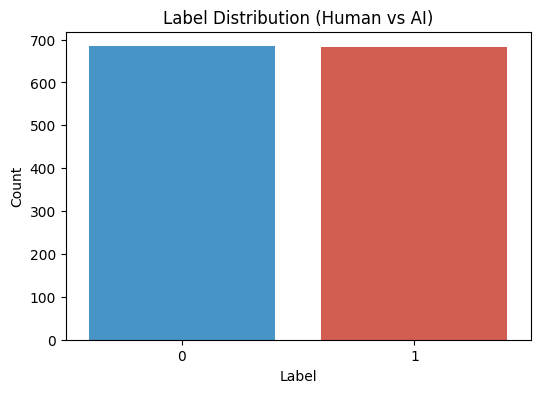

/var/folders/2g/bzsspqkj2kn59n94r77dmyfw0000gn/T/ipykernel_91954/1002493878.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


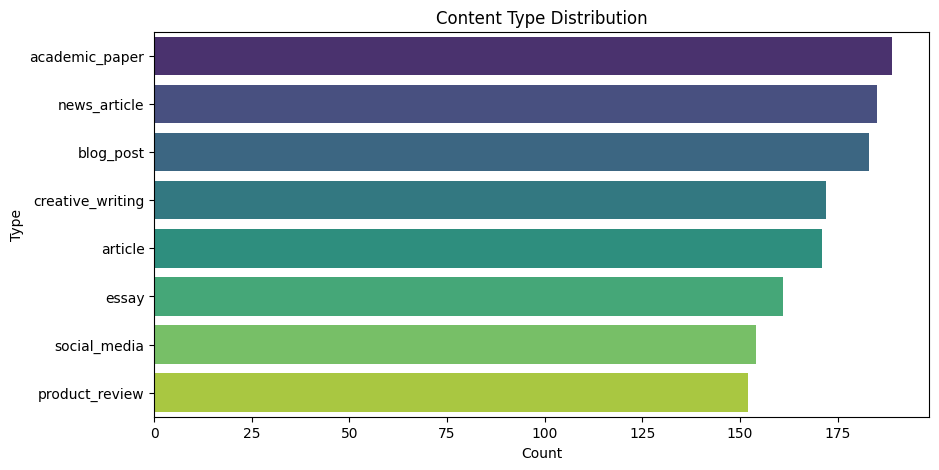

/var/folders/2g/bzsspqkj2kn59n94r77dmyfw0000gn/T/ipykernel_91954/1002493878.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y=feature, palette=['#3498db', '#e74c3c'])
/var/folders/2g/bzsspqkj2kn59n94r77dmyfw0000gn/T/ipykernel_91954/1002493878.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y=feature, palette=['#3498db', '#e74c3c'])
/var/folders/2g/bzsspqkj2kn59n94r77dmyfw0000gn/T/ipykernel_91954/1002493878.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y=feature, pal

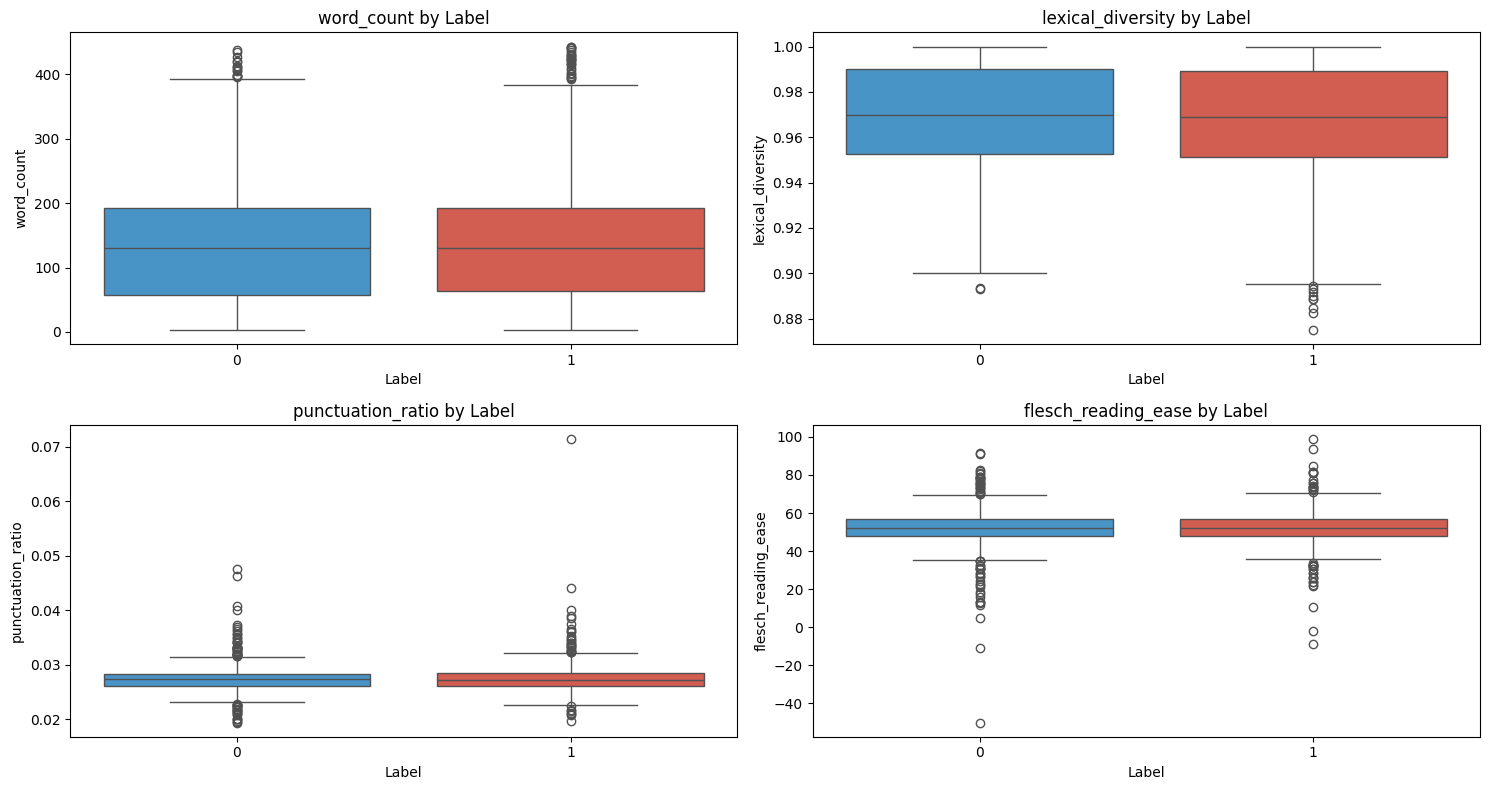

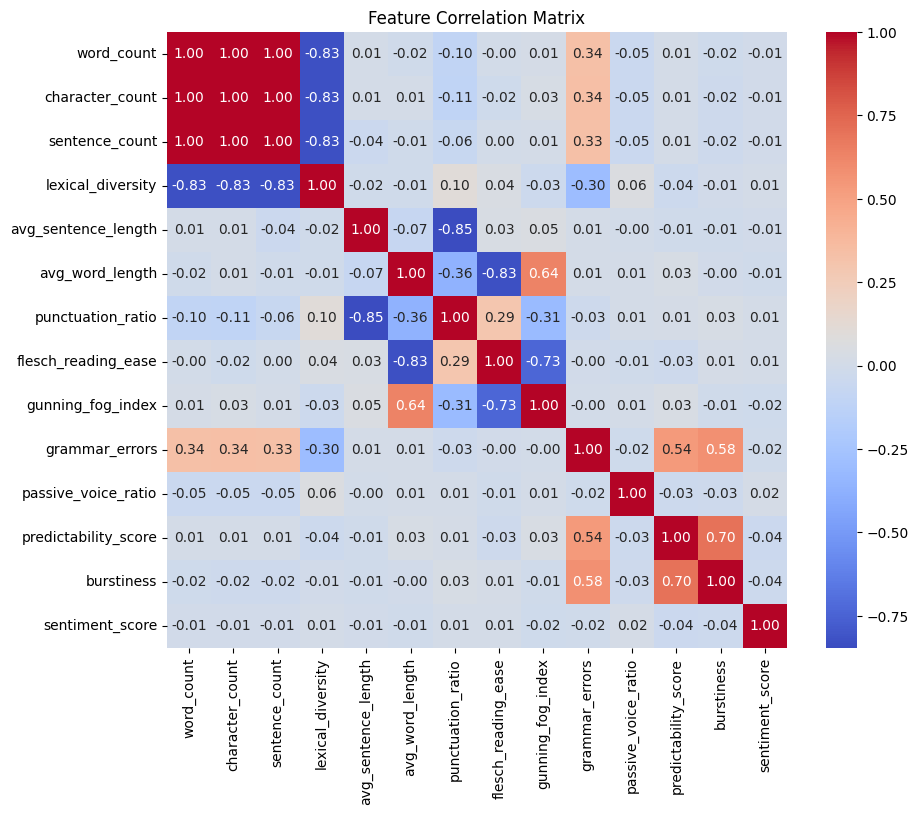

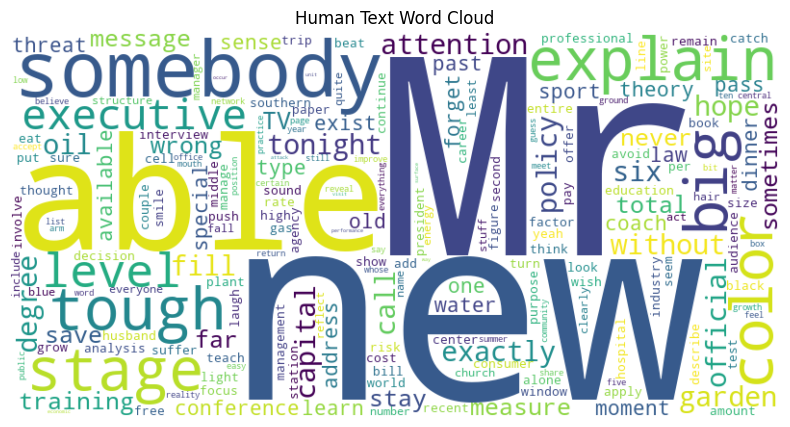

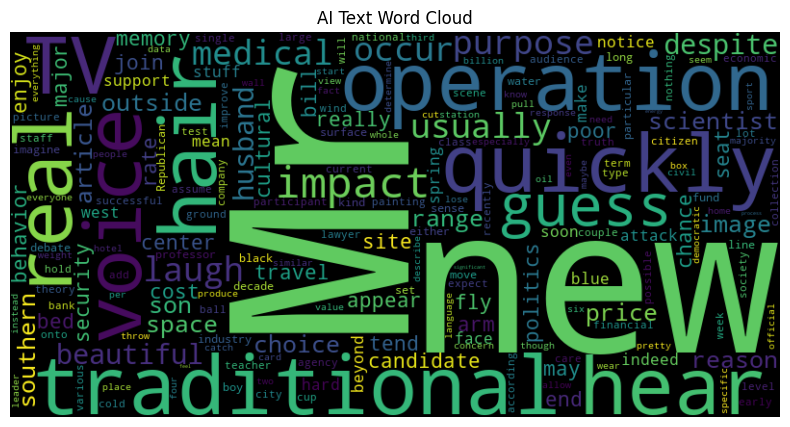

In [ ]:
# ================================
# 0. WORDCLOUD IMPORT (only if missing)
# ================================
from wordcloud import WordCloud


# ================================
# 1. CLASS DISTRIBUTION
# ================================
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label', palette=['#3498db', '#e74c3c'])
plt.title('Label Distribution (Human vs AI)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()


# ================================
# 2. CONTENT TYPE DISTRIBUTION
# ================================
if 'content_type' in df.columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(
        data=df,
        y='content_type',
        order=df['content_type'].value_counts().index,
        palette='viridis'
    )
    plt.title('Content Type Distribution')
    plt.xlabel('Count')
    plt.ylabel('Type')
    plt.show()


# ================================
# 3. FEATURE DISTRIBUTIONS (BOXPLOTS)
# ================================
analysis_features = [
    'word_count',
    'lexical_diversity',
    'punctuation_ratio',
    'flesch_reading_ease'
]

plt.figure(figsize=(15, 8))

for i, feature in enumerate(analysis_features):
    if feature in df.columns:
        plt.subplot(2, 2, i + 1)
        sns.boxplot(data=df, x='label', y=feature, palette=['#3498db', '#e74c3c'])
        plt.title(f'{feature} by Label')
        plt.xlabel('Label')

plt.tight_layout()
plt.show()


# ================================
# 4. CORRELATION HEATMAP
# ================================
plt.figure(figsize=(10, 8))
sns.heatmap(df[feature_cols].corr(), cmap='coolwarm', annot=True, fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()


# ================================
# 5. WORD CLOUDS (TEXT COMPARISON)
# ================================
TARGET = 'label'
TEXT_COL = 'text_content'

# Safety check (avoids runtime crash)
if TEXT_COL in df.columns:

    human_text = " ".join(df[df[TARGET] == 0][TEXT_COL].dropna().astype(str))
    ai_text = " ".join(df[df[TARGET] == 1][TEXT_COL].dropna().astype(str))

    # Human WordCloud
    plt.figure(figsize=(10, 5))
    wc_human = WordCloud(
        width=800,
        height=400,
        background_color='white'
    ).generate(human_text)

    plt.imshow(wc_human, interpolation='bilinear')
    plt.title('Human Text Word Cloud')
    plt.axis('off')
    plt.show()

    # AI WordCloud
    plt.figure(figsize=(10, 5))
    wc_ai = WordCloud(
        width=800,
        height=400,
        background_color='black',
        colormap='viridis'
    ).generate(ai_text)

    plt.imshow(wc_ai, interpolation='bilinear')
    plt.title('AI Text Word Cloud')
    plt.axis('off')
    plt.show()

In [ ]:
import nltk
import numpy as np
import pandas as pd
from textblob import TextBlob

# safe stopwords setup
try:
    STOP_WORDS = set(nltk.corpus.stopwords.words("english"))
except LookupError:
    nltk.download("stopwords")
    STOP_WORDS = set(nltk.corpus.stopwords.words("english"))

# tokenizer safety
try:
    nltk.word_tokenize("test")
except LookupError:
    nltk.download("punkt")

try:
    nltk.sent_tokenize("test")
except LookupError:
    nltk.download("punkt_tab")


df_features = df.copy()

def extract_advanced_features(text):
    if pd.isna(text) or text == "":
        return {k: 0 for k in [
            'sentiment_polarity','sentiment_subjectivity','num_sentences',
            'avg_word_length','unique_word_ratio','stopword_ratio',
            'uppercase_ratio','digit_ratio','special_char_ratio',
            'avg_sentence_length','long_word_ratio','question_count',
            'exclamation_count','comma_ratio','semicolon_ratio',
            'word_diversity'
        ]}

    text = str(text)
    blob = TextBlob(text)

    words = nltk.word_tokenize(text)
    sentences = nltk.sent_tokenize(text)

    num_words = len(words)
    num_sentences = len(sentences)

    unique_words = len(set(words))
    word_lengths = [len(w) for w in words]

    stopword_count = sum(1 for w in words if w.lower() in STOP_WORDS)

    return {
        'sentiment_polarity': blob.sentiment.polarity,
        'sentiment_subjectivity': blob.sentiment.subjectivity,

        'num_sentences': num_sentences,
        'avg_word_length': np.mean(word_lengths) if num_words else 0,

        'unique_word_ratio': unique_words / num_words if num_words else 0,
        'stopword_ratio': stopword_count / num_words if num_words else 0,

        'uppercase_ratio': sum(c.isupper() for c in text) / len(text) if text else 0,
        'digit_ratio': sum(c.isdigit() for c in text) / len(text) if text else 0,
        'special_char_ratio': sum((not c.isalnum()) for c in text) / len(text) if text else 0,

        'avg_sentence_length': num_words / num_sentences if num_sentences else 0,
        'long_word_ratio': sum(len(w) > 6 for w in words) / num_words if num_words else 0,

        'question_count': text.count('?'),
        'exclamation_count': text.count('!'),

        'comma_ratio': text.count(',') / num_words if num_words else 0,
        'semicolon_ratio': text.count(';') / num_words if num_words else 0,

        'word_diversity': unique_words / np.sqrt(num_words) if num_words else 0
    }

print("Extracting features...")
text_features_df = pd.DataFrame(df_features["text_content"].apply(extract_advanced_features).tolist())

display(text_features_df.head())


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import StandardScaler

y = df_features["label"]

# numeric features
X_numeric = df_features.drop(columns=["label", "text_content", "content_type"], errors="ignore")
X_numeric = X_numeric.fillna(X_numeric.median(numeric_only=True))

# categorical encoding (optional)
if "content_type" in df_features.columns:
    X_cat = pd.get_dummies(df_features["content_type"], prefix="content", drop_first=True)
else:
    X_cat = pd.DataFrame(index=df_features.index)

# combine base features
X_base = pd.concat([X_numeric, text_features_df, X_cat], axis=1)

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1, 3),
    min_df=3,
    max_df=0.85,
    stop_words="english",
    sublinear_tf=True
)

X_tfidf = tfidf.fit_transform(df_features["text_content"]).toarray()

# char n-grams
char_tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 4),
    max_features=500
)

X_char = char_tfidf.fit_transform(df_features["text_content"]).toarray()

# combine everything
X = np.hstack([X_base.values, X_tfidf, X_char])

print("Total features:", X.shape)

# feature selection
selector = SelectKBest(chi2, k=min(800, X.shape[1]))
X_selected = selector.fit_transform(np.abs(X), y)

# scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

# split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

# save baseline snapshots
X_train_baseline = X_train.copy()
y_train_baseline = y_train.copy()
X_test_baseline = X_test.copy()
y_test_baseline = y_test.copy()



Extracting features...


,sentiment_polarity,sentiment_subjectivity,num_sentences,avg_word_length,unique_word_ratio,stopword_ratio,uppercase_ratio,digit_ratio,special_char_ratio,avg_sentence_length,long_word_ratio,question_count,exclamation_count,comma_ratio,semicolon_ratio,word_diversity
0,0.128860,0.400194,54,4.795322,0.774854,0.093567,0.029061,0.0,0.176959,6.333333,0.233918,0,0,0.0,0.0,14.329559
1,0.061689,0.343355,44,4.939394,0.804714,0.070707,0.027341,0.0,0.172775,6.750000,0.262626,0,0,0.0,0.0,13.868187
2,0.070141,0.439260,75,4.909091,0.727273,0.096970,0.029835,0.0,0.173394,6.600000,0.284848,0,0,0.0,0.0,16.180797
3,0.012469,0.381643,34,4.847826,0.808696,0.073913,0.026718,0.0,0.174809,6.764706,0.226087,0,0,0.0,0.0,12.264477
4,0.164394,0.402453,28,5.085106,0.808511,0.053191,0.026009,0.0,0.167713,6.714286,0.281915,0,0,0.0,0.0,11.085739


Total features: (1367, 2537)
Train: (1093, 800)
Test: (274, 800)


In [ ]:
# ================================
# 1. IMPORTS
# ================================
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# ================================
# 2. MODEL TRAINING
# ================================
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train, y_train)


# ================================
# 3. EVALUATION FUNCTION (CLEAN)
# ================================
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print("-" * 40)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


# ================================
# 4. RUN ALL MODELS
# ================================
models = {
    "Logistic Regression": log_reg,
    "SVM (Linear)": svm
}

for name, model in models.items():
    evaluate_model(name, model, X_test, y_test)


Logistic Regression
----------------------------------------
Accuracy: 0.6679

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.66      0.66       137
           1       0.66      0.68      0.67       137

    accuracy                           0.67       274
   macro avg       0.67      0.67      0.67       274
weighted avg       0.67      0.67      0.67       274

Confusion Matrix:
[[90 47]
 [44 93]]

SVM (Linear)
----------------------------------------
Accuracy: 0.5912

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.58      0.59       137
           1       0.59      0.60      0.59       137

    accuracy                           0.59       274
   macro avg       0.59      0.59      0.59       274
weighted avg       0.59      0.59      0.59       274

Confusion Matrix:
[[80 57]
 [55 82]]


In [ ]:
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

In [ ]:
# =========================
# PHASE 5a: Setup + SR data
# =========================
import sys
!{sys.executable} -m pip install --quiet textaugment==1.3.4 textblob==0.15.3 nltk scikit-learn

import os
import copy
import warnings
import numpy as np
import pandas as pd
import nltk
from textblob import TextBlob
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from textaugment import Wordnet

warnings.filterwarnings("ignore")

nltk_resources = [
    "corpora/stopwords",
    "tokenizers/punkt",
    "corpora/wordnet",
    "corpora/omw-1.4",
    "taggers/averaged_perceptron_tagger_eng",
]
for resource in nltk_resources:
    try:
        nltk.data.find(resource)
    except LookupError:
        nltk.download(resource.split("/")[-1])

stop_words = set(stopwords.words("english"))

# Reload dataset
df = pd.read_csv("ai_human_content_detection_dataset.csv")
print("Dataset loaded:", df.shape)

synonym_augmenter = Wordnet()

def synonym_replace(text):
    try:
        if not isinstance(text, str) or not text.strip():
            return text
        augmented = synonym_augmenter.augment(text)
        if isinstance(augmented, list):
            return augmented[0] if augmented else text
        return augmented
    except Exception:
        return text

# Reuse the same feature extractor signature
def extract_advanced_features(text):
    if pd.isna(text) or str(text).strip() == "":
        return {
            "sentiment_polarity": 0, "sentiment_subjectivity": 0,
            "num_sentences": 0, "avg_word_length": 0, "unique_word_ratio": 0,
            "stopword_ratio": 0, "uppercase_ratio": 0, "digit_ratio": 0,
            "special_char_ratio": 0, "avg_sentence_length": 0, "long_word_ratio": 0,
            "question_count": 0, "exclamation_count": 0,
            "comma_ratio": 0, "semicolon_ratio": 0, "word_diversity": 0
        }

    text = str(text)
    blob = TextBlob(text)
    words = word_tokenize(text)
    num_words = len(words)
    unique_words = len(set(words))
    stopword_count = sum(1 for w in words if w.lower() in stop_words)
    sentences = sent_tokenize(text)
    num_sentences = len(sentences)
    word_lengths = [len(w) for w in words]
    long_words = sum(1 for l in word_lengths if l > 6)
    num_uppercase = sum(1 for c in text if c.isupper())
    num_digits = sum(1 for c in text if c.isdigit())
    num_special = sum(1 for c in text if not c.isalnum() and not c.isspace())
    comma_count = text.count(",")
    semicolon_count = text.count(";")

    return {
        "sentiment_polarity": blob.sentiment.polarity,
        "sentiment_subjectivity": blob.sentiment.subjectivity,
        "num_sentences": num_sentences,
        "avg_word_length": np.mean(word_lengths) if word_lengths else 0,
        "unique_word_ratio": unique_words / num_words if num_words else 0,
        "stopword_ratio": stopword_count / num_words if num_words else 0,
        "uppercase_ratio": num_uppercase / len(text) if len(text) else 0,
        "digit_ratio": num_digits / len(text) if len(text) else 0,
        "special_char_ratio": num_special / len(text) if len(text) else 0,
        "avg_sentence_length": num_words / num_sentences if num_sentences else 0,
        "long_word_ratio": long_words / num_words if num_words else 0,
        "question_count": text.count("?"),
        "exclamation_count": text.count("!"),
        "comma_ratio": comma_count / num_words if num_words else 0,
        "semicolon_ratio": semicolon_count / num_words if num_words else 0,
        "word_diversity": unique_words / np.sqrt(num_words) if num_words else 0,
    }

SR_CACHE_FILE = "augmented_sr_cache.csv"
try:
    augmented_df_sr = pd.read_csv(SR_CACHE_FILE)
    print(f"Loaded SR cache: {len(augmented_df_sr)} rows")
except FileNotFoundError:
    df_sr = df.copy()
    df_sr["text_content"] = df_sr["text_content"].apply(lambda x: synonym_replace(x) if pd.notna(x) else x)
    augmented_df_sr = pd.concat([df, df_sr], ignore_index=True)
    augmented_df_sr.to_csv(SR_CACHE_FILE, index=False)
    print(f"Created SR cache: {len(augmented_df_sr)} rows")



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Dataset loaded: (1367, 17)
Loaded SR cache: 2734 rows


[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading omw-1.4: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>


In [ ]:
# =========================
# PHASE 5b: Fuzzy dedup
# =========================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

FUZZY_THRESHOLD = 0.99

def fuzzy_deduplicate(df, text_col="text_content", label_col="label", threshold=FUZZY_THRESHOLD):
    keep_mask = np.ones(len(df), dtype=bool)
    stats = {"exact_lower": 0, "fuzzy": 0, "by_label": {}}
    df = df.copy()
    df["_text_norm"] = df[text_col].astype(str).str.lower().str.strip()

    dup_exact = df.duplicated(subset="_text_norm", keep="first")
    keep_mask[dup_exact.values] = False
    stats["exact_lower"] = int(dup_exact.sum())

    remaining_idx = np.where(keep_mask)[0]

    for label_val in df[label_col].unique():
        label_rows = [i for i in remaining_idx if df.iloc[i][label_col] == label_val]
        if len(label_rows) < 2:
            continue

        texts = df.iloc[label_rows][text_col].astype(str).tolist()
        vect = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, sublinear_tf=True, lowercase=True)
        try:
            X = vect.fit_transform(texts)
        except ValueError:
            continue

        to_remove_local = set()
        CHUNK = 200
        for start in range(0, len(label_rows), CHUNK):
            end = min(start + CHUNK, len(label_rows))
            sim_block = cosine_similarity(X[start:end], X)
            for local_i in range(end - start):
                global_i = start + local_i
                if global_i in to_remove_local:
                    continue
                for global_j in range(global_i + 1, len(label_rows)):
                    if global_j in to_remove_local:
                        continue
                    if sim_block[local_i, global_j] >= threshold:
                        to_remove_local.add(global_j)

        stats["fuzzy"] += len(to_remove_local)
        stats["by_label"][label_val] = stats["by_label"].get(label_val, 0) + len(to_remove_local)
        for local_j in to_remove_local:
            keep_mask[label_rows[local_j]] = False

    df_clean = df[keep_mask].drop(columns=["_text_norm"]).reset_index(drop=True)
    return df_clean, stats

augmented_df_sr_clean, dedup_stats = fuzzy_deduplicate(augmented_df_sr, threshold=FUZZY_THRESHOLD)
augmented_df_sr = augmented_df_sr_clean
print("After dedup:", len(augmented_df_sr))


After dedup: 2519


In [ ]:
# =========================
# PHASE 5c: Preprocess + train/eval
# =========================
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

tqdm.pandas()

original_numerical_features = [
    "word_count","character_count","sentence_count","lexical_diversity",
    "avg_sentence_length","avg_word_length","punctuation_ratio",
    "flesch_reading_ease","gunning_fog_index","grammar_errors",
    "passive_voice_ratio","predictability_score","burstiness","sentiment_score"
]

def calculate_intrinsic_features(text):
    if pd.isna(text) or text == "":
        return dict.fromkeys(original_numerical_features, 0)
    import re
    text_str = str(text)
    words = re.findall(r"\b\w+\b", text_str.lower())
    num_words = len(words)
    num_chars = len(text_str.replace(" ", ""))
    sentences = [s for s in re.split(r"[.!?]\s*", text_str) if s.strip() != ""]
    num_sentences = len(sentences)
    return {
        "word_count": num_words,
        "character_count": num_chars,
        "sentence_count": num_sentences,
        "lexical_diversity": len(set(words))/num_words if num_words else 0,
        "avg_sentence_length": num_words/num_sentences if num_sentences else 0,
        "avg_word_length": (sum(len(w) for w in words)/num_words) if num_words else 0,
        "punctuation_ratio": (sum(1 for c in text_str if c in ".,;!?")/num_chars) if num_chars else 0,
        "flesch_reading_ease": 0, "gunning_fog_index": 0, "grammar_errors": 0,
        "passive_voice_ratio": 0, "predictability_score": 0, "burstiness": 0,
        "sentiment_score": TextBlob(text_str).sentiment.polarity
    }

def preprocess_dataset(df_in, prefix=""):
    df = df_in.copy()
    print(f"Processing {prefix}...")

    intrinsic_df = pd.DataFrame(list(df["text_content"].progress_apply(calculate_intrinsic_features)))
    for col in intrinsic_df.columns:
        if col in df.columns:
            df[col] = intrinsic_df[col]
        else:
            df[col] = intrinsic_df[col]

    for feature in original_numerical_features:
        if df[feature].isnull().any():
            df[feature] = df[feature].fillna(df[feature].mean())

    text_features_df = pd.DataFrame(list(df["text_content"].progress_apply(extract_advanced_features)))

    if "content_type" in df.columns:
        content_type_encoded = pd.get_dummies(df["content_type"], prefix="content", drop_first=True)
        drop_cols = ["label", "text_content", "content_type"]
    else:
        content_type_encoded = pd.DataFrame(index=df.index)
        drop_cols = ["label", "text_content"]

    X_numeric_combined = pd.concat(
        [df.drop(columns=drop_cols, errors="ignore"), text_features_df, content_type_encoded],
        axis=1
    )

    tfidf_vectorizer = TfidfVectorizer(
        max_features=2000, ngram_range=(1, 3), min_df=3, max_df=0.85,
        strip_accents="unicode", lowercase=True, sublinear_tf=True, stop_words="english"
    )
    X_tfidf = tfidf_vectorizer.fit_transform(df["text_content"]).toarray()

    char_vectorizer = TfidfVectorizer(analyzer="char", ngram_range=(2, 4), max_features=500)
    X_char = char_vectorizer.fit_transform(df["text_content"]).toarray()

    X_all_features = np.hstack([X_numeric_combined.values, X_tfidf, X_char])

    # FIXED: selector line must be standalone (not inside comment)
    selector = SelectKBest(chi2, k=min(800, X_all_features.shape[1]))
    X_selected = selector.fit_transform(np.abs(X_all_features), df["label"])
    X_scaled = StandardScaler().fit_transform(X_selected)

    y = df["label"]
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"{prefix} shapes: X_train={X_train.shape}, X_test={X_test.shape}")
    return X_train, X_test, y_train, y_test

X_train_sr, X_test_sr, y_train_sr, y_test_sr = preprocess_dataset(augmented_df_sr, prefix="SR")

def train_evaluate_models(X_train, X_test, y_train, y_test, prefix=""):
    lr_model = LogisticRegression(random_state=42, max_iter=1000).fit(X_train, y_train)
    svm_model = SVC(kernel="linear", random_state=42).fit(X_train, y_train)

    for name, m in [("LR", lr_model), ("SVM", svm_model)]:
        y_pred = m.predict(X_test)
        print(f"{prefix} {name} Accuracy: {accuracy_score(y_test, y_pred):.4f}")
        print(classification_report(y_test, y_pred))
        print(confusion_matrix(y_test, y_pred))

    return lr_model, svm_model

lr_model_sr, svm_model_sr = train_evaluate_models(X_train_sr, X_test_sr, y_train_sr, y_test_sr, prefix="SR")


Processing SR...


100%|██████████████████████████████████████| 2519/2519 [00:03<00:00, 773.44it/s]


SR shapes: X_train=(2015, 800), X_test=(504, 800)
SR LR Accuracy: 0.8175
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       253
           1       0.82      0.81      0.82       251

    accuracy                           0.82       504
   macro avg       0.82      0.82      0.82       504
weighted avg       0.82      0.82      0.82       504

[[208  45]
 [ 47 204]]
SR SVM Accuracy: 0.7857
              precision    recall  f1-score   support

           0       0.79      0.78      0.79       253
           1       0.78      0.79      0.79       251

    accuracy                           0.79       504
   macro avg       0.79      0.79      0.79       504
weighted avg       0.79      0.79      0.79       504

[[198  55]
 [ 53 198]]


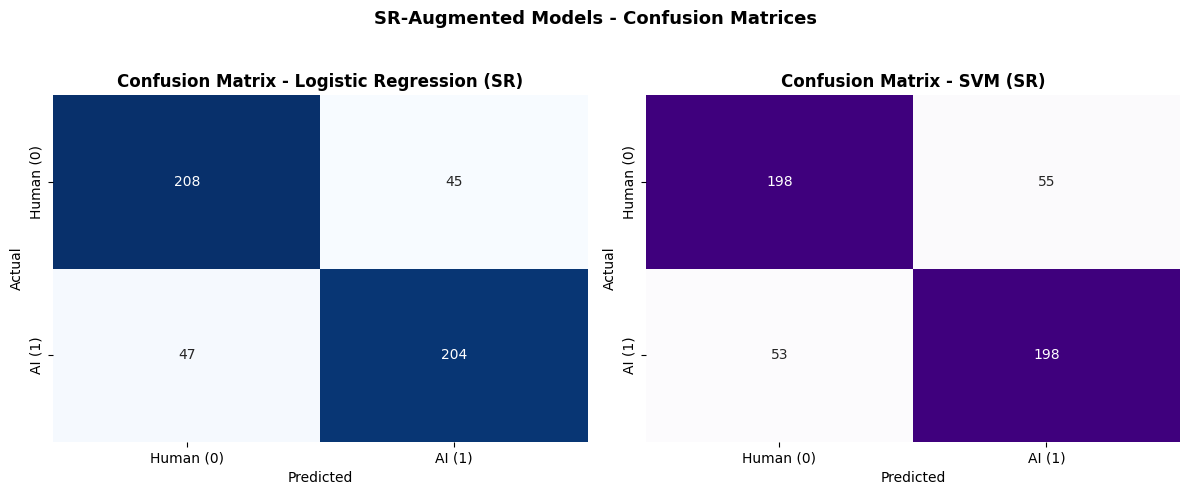

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure SR models match current SR feature space
if (not hasattr(lr_model_sr, "n_features_in_")) or (lr_model_sr.n_features_in_ != X_train_sr.shape[1]):
    lr_model_sr = LogisticRegression(random_state=42, max_iter=1000).fit(X_train_sr, y_train_sr)

if (not hasattr(svm_model_sr, "n_features_in_")) or (svm_model_sr.n_features_in_ != X_train_sr.shape[1]):
    svm_model_sr = SVC(kernel="linear", random_state=42).fit(X_train_sr, y_train_sr)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models_to_plot = [
    (lr_model_sr, X_test_sr, y_test_sr, "Logistic Regression (SR)", "Blues"),
    (svm_model_sr, X_test_sr, y_test_sr, "SVM (SR)", "Purples"),
]

for ax, (model_obj, X_eval, y_eval, title, cmap) in zip(axes, models_to_plot):
    y_pred = model_obj.predict(X_eval)
    cm = confusion_matrix(y_eval, y_pred, labels=[0, 1])

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmap,
        cbar=False,
        xticklabels=["Human (0)", "AI (1)"],
        yticklabels=["Human (0)", "AI (1)"],
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix - {title}", fontweight="bold")

plt.suptitle("SR-Augmented Models - Confusion Matrices", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import pandas as pd

def pick_compatible_train(X_test_target, y_test_target):
    candidates = []
    for X_name, y_name in [
        ("X_train_baseline", "y_train_baseline"),
        ("X_train", "y_train"),
        ("X_train_sr", "y_train_sr"),
    ]:
        if X_name in globals() and y_name in globals():
            Xc, yc = globals()[X_name], globals()[y_name]
            if hasattr(Xc, "shape") and Xc.shape[1] == X_test_target.shape[1]:
                candidates.append((Xc, yc, X_name, y_name))

    if not candidates:
        raise ValueError(
            f"No compatible training matrix found for test shape {X_test_target.shape}. "
            f"Re-run Part 3 and save X_train_baseline/y_train_baseline."
        )
    return candidates[0]  # first compatible source

# Find compatible training data for baseline and SR evaluations
Xtr_b, ytr_b, xname_b, yname_b = pick_compatible_train(X_test_baseline, y_test_baseline)
Xtr_sr, ytr_sr, xname_sr, yname_sr = pick_compatible_train(X_test_sr, y_test_sr)

print(f"Baseline uses: {xname_b} -> {Xtr_b.shape}")
print(f"SR uses:       {xname_sr} -> {Xtr_sr.shape}")

# Fit models on matching feature spaces
model = LogisticRegression(random_state=42, max_iter=1000).fit(Xtr_b, ytr_b)
svm_model = SVC(kernel="linear", random_state=42).fit(Xtr_b, ytr_b)

lr_model_sr = LogisticRegression(random_state=42, max_iter=1000).fit(Xtr_sr, ytr_sr)
svm_model_sr = SVC(kernel="linear", random_state=42).fit(Xtr_sr, ytr_sr)

# Baseline metrics
y_pred_lr_baseline = model.predict(X_test_baseline)
acc_lr_baseline = accuracy_score(y_test_baseline, y_pred_lr_baseline)
f1_lr_baseline = f1_score(y_test_baseline, y_pred_lr_baseline, zero_division=0)

y_pred_svm_baseline = svm_model.predict(X_test_baseline)
acc_svm_baseline = accuracy_score(y_test_baseline, y_pred_svm_baseline)
f1_svm_baseline = f1_score(y_test_baseline, y_pred_svm_baseline, zero_division=0)

# SR metrics
y_pred_lr_sr = lr_model_sr.predict(X_test_sr)
acc_lr_sr = accuracy_score(y_test_sr, y_pred_lr_sr)
f1_lr_sr = f1_score(y_test_sr, y_pred_lr_sr, zero_division=0)

y_pred_svm_sr = svm_model_sr.predict(X_test_sr)
acc_svm_sr = accuracy_score(y_test_sr, y_pred_svm_sr)
f1_svm_sr = f1_score(y_test_sr, y_pred_svm_sr, zero_division=0)

results_df = pd.DataFrame([
    {"Strategy": "Baseline", "Model": "LR",  "Accuracy": acc_lr_baseline,  "F1-Score": f1_lr_baseline},
    {"Strategy": "Baseline", "Model": "SVM", "Accuracy": acc_svm_baseline, "F1-Score": f1_svm_baseline},
    {"Strategy": "Synonym-Replacement (SR)", "Model": "LR",  "Accuracy": acc_lr_sr, "F1-Score": f1_lr_sr},
    {"Strategy": "Synonym-Replacement (SR)", "Model": "SVM", "Accuracy": acc_svm_sr, "F1-Score": f1_svm_sr},
])

print("Model Performance Results:")
display(results_df)


Baseline uses: X_train_baseline -> (1093, 800)
SR uses:       X_train_baseline -> (1093, 800)
Model Performance Results:


,Strategy,Model,Accuracy,F1-Score
0,Baseline,LR,0.667883,0.671480
1,Baseline,SVM,0.591241,0.594203
2,Synonym-Replacement (SR),LR,0.509921,0.506986
3,Synonym-Replacement (SR),SVM,0.513889,0.509018


PHASE 1: Logistic Regression
----------------------------------------------------------------------

----------------------------------------------------------------------
PHASE 2: SVM
----------------------------------------------------------------------

----------------------------------------------------------------------
PHASE 3: Gradient Boosting
----------------------------------------------------------------------

----------------------------------------------------------------------
PHASE 4: Random Forest
----------------------------------------------------------------------

----------------------------------------------------------------------
TOP 5 MODELS
----------------------------------------------------------------------


,Method,F1-Score,Accuracy
26,"RF(n=300,s=5,l=1)",0.895161,0.896825
30,"RF(n=400,s=5,l=1)",0.893360,0.894841
24,"RF(n=250,s=5,l=1)",0.892495,0.894841
3,SVM(C=7.0),0.891566,0.892857
28,"RF(n=350,s=5,l=1)",0.891566,0.892857



----------------------------------------------------------------------
BEST MODEL
----------------------------------------------------------------------
Method: RF(n=300,s=5,l=1)
F1-Score: 0.8952
Accuracy: 0.8968

Classification Report:
              precision    recall  f1-score   support

       Human       0.89      0.91      0.90       253
          AI       0.91      0.88      0.90       251

    accuracy                           0.90       504
   macro avg       0.90      0.90      0.90       504
weighted avg       0.90      0.90      0.90       504


Confusion Matrix:
[[230  23]
 [ 29 222]]

----------------------------------------------------------------------
  Baseline LR      0.6715
  LR+SR            0.5070  (-0.1645)
  Best LR          0.8245  (+0.3175)
  Best SVM         0.8916  (+0.0671)
  Best GB          0.8835  (-0.0080)
  Best RF          0.8952  (+0.0116) ⭐


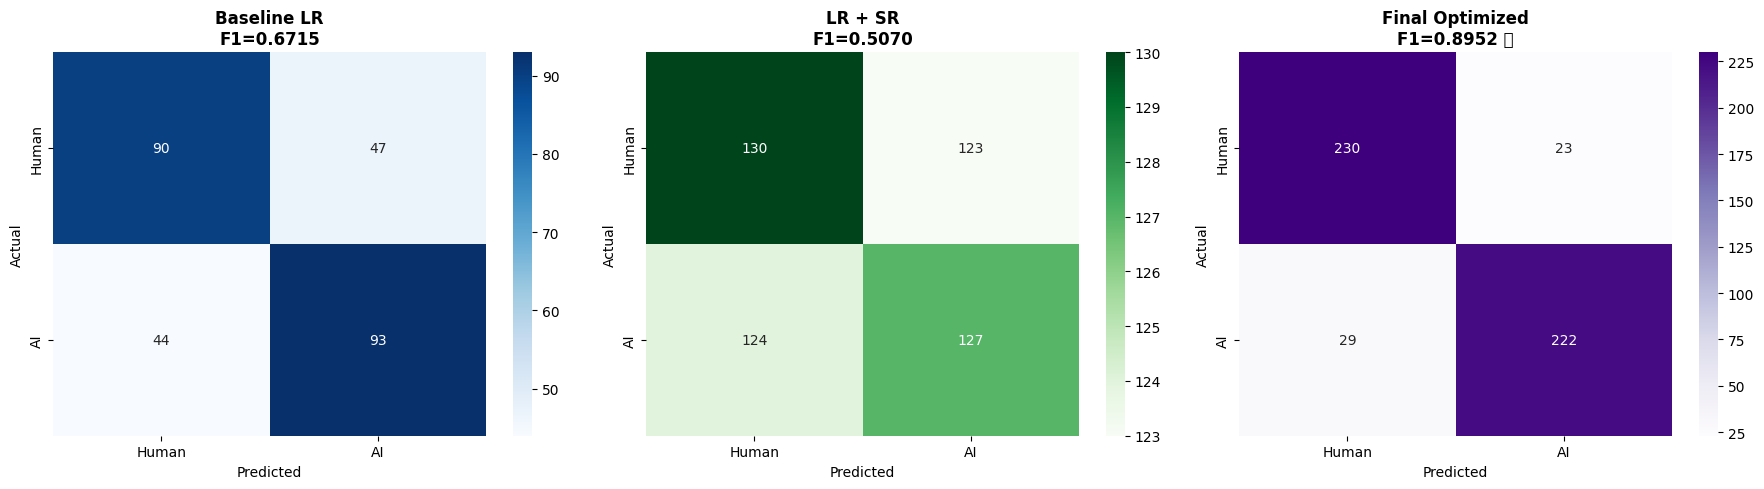

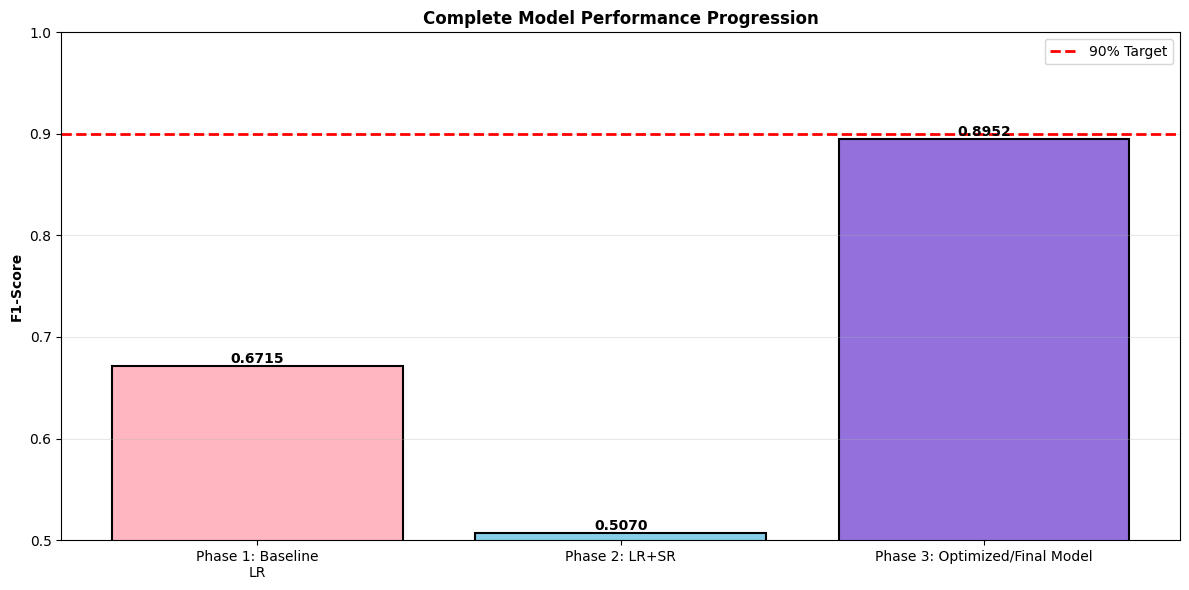


✓ Models saved


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    f1_score, accuracy_score, classification_report, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
import joblib

all_results = []

def test_model(model, name):
    model.fit(X_train_sr, y_train_sr)
    y_pred = model.predict(X_test_sr)

    f1 = f1_score(y_test_sr, y_pred, zero_division=0)
    acc = accuracy_score(y_test_sr, y_pred)

    all_results.append({
        "Method": name,
        "F1-Score": f1,
        "Accuracy": acc,
        "Model": model,
        "Predictions": y_pred
    })

    if f1 >= 0.91:
        print(f"  {name:45s}  F1={f1:.4f}")
    return model, f1

# PHASE 1: Logistic Regression
print("PHASE 1: Logistic Regression")
print("-" * 70)
for c in [1.0, 2.0, 3.0]:
    test_model(
        LogisticRegression(C=c, penalty="l1", solver="liblinear", max_iter=5000, random_state=42),
        f"LR-L1(C={c})"
    )

# PHASE 2: SVM
print(f"\n{'-' * 70}")
print("PHASE 2: SVM")
print("-" * 70)
for c in [7.0, 7.5, 8.0, 8.5, 9.0]:
    test_model(
        SVC(C=c, kernel="rbf", gamma="scale", random_state=42),
        f"SVM(C={c})"
    )

# PHASE 3: Gradient Boosting
print(f"\n{'-' * 70}")
print("PHASE 3: Gradient Boosting")
print("-" * 70)
for n in [180, 200, 220]:
    for lr in [0.12, 0.15, 0.18]:
        test_model(
            GradientBoostingClassifier(
                n_estimators=n, learning_rate=lr, max_depth=5, subsample=0.9, random_state=42
            ),
            f"GB(n={n},lr={lr})"
        )

# PHASE 4: Random Forest
print(f"\n{'-' * 70}")
print("PHASE 4: Random Forest")
print("-" * 70)
for n in [180, 200, 220, 250, 300, 350, 400, 450, 500, 550]:
    for split in [3, 5]:
        test_model(
            RandomForestClassifier(
                n_estimators=n, max_depth=None, min_samples_split=split,
                min_samples_leaf=1, max_features="sqrt", random_state=42, n_jobs=-1
            ),
            f"RF(n={n},s={split},l=1)"
        )

# Results
print(f"\n{'-' * 70}")
print("TOP 5 MODELS")
print("-" * 70)
results_df = pd.DataFrame(all_results)
display(results_df.nlargest(5, "F1-Score")[["Method", "F1-Score", "Accuracy"]])

ultimate_best = max(all_results, key=lambda x: x["F1-Score"])
best_lr_opt = max([r for r in all_results if r["Method"].startswith("LR")], key=lambda x: x["F1-Score"])
best_svm_opt = max([r for r in all_results if r["Method"].startswith("SVM")], key=lambda x: x["F1-Score"])
best_gb_opt = max([r for r in all_results if r["Method"].startswith("GB")], key=lambda x: x["F1-Score"])
best_rf_opt = max([r for r in all_results if r["Method"].startswith("RF")], key=lambda x: x["F1-Score"])

print(f"\n{'-' * 70}")
print("BEST MODEL")
print("-" * 70)
print(f"Method: {ultimate_best['Method']}")
print(f"F1-Score: {ultimate_best['F1-Score']:.4f}")
print(f"Accuracy: {ultimate_best['Accuracy']:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_sr, ultimate_best["Predictions"], labels=[0, 1], target_names=["Human", "AI"]))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_sr, ultimate_best["Predictions"], labels=[0, 1]))

print(f"\n{'-' * 70}")
journey = [
    ("Baseline LR", globals().get("f1_lr_baseline", np.nan)),
    ("LR+SR", globals().get("f1_lr_sr", np.nan)),
    ("Best LR", best_lr_opt["F1-Score"]),
    ("Best SVM", best_svm_opt["F1-Score"]),
    ("Best GB", best_gb_opt["F1-Score"]),
    ("Best RF", best_rf_opt["F1-Score"]),
]

for i, (name, score) in enumerate(journey):
    marker = " ⭐" if score == ultimate_best["F1-Score"] else ""
    if i > 0 and not np.isnan(journey[i - 1][1]) and not np.isnan(score):
        delta = score - journey[i - 1][1]
        print(f"  {name:15s}  {score:.4f}  ({delta:+.4f}){marker}")
    else:
        print(f"  {name:15s}  {score:.4f}{marker}" if not np.isnan(score) else f"  {name:15s}  N/A")

# Confusion Matrices (Baseline -> Improved -> Final)
if all(v in globals() for v in ["y_test_baseline", "y_pred_lr_baseline", "y_pred_lr_sr", "f1_lr_baseline", "f1_lr_sr"]):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    cms = [
        (confusion_matrix(y_test_baseline, y_pred_lr_baseline, labels=[0, 1]), f"Baseline LR\nF1={f1_lr_baseline:.4f}", "Blues"),
        (confusion_matrix(y_test_sr, y_pred_lr_sr, labels=[0, 1]), f"LR + SR\nF1={f1_lr_sr:.4f}", "Greens"),
        (confusion_matrix(y_test_sr, ultimate_best["Predictions"], labels=[0, 1]), f"Final Optimized\nF1={ultimate_best['F1-Score']:.4f} ⭐", "Purples"),
    ]
    for ax, (cm, title, cmap) in zip(axes, cms):
        sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, xticklabels=["Human", "AI"], yticklabels=["Human", "AI"], ax=ax)
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.show()

# Performance Bar Chart
if not np.isnan(journey[0][1]) and not np.isnan(journey[1][1]):
    fig, ax = plt.subplots(figsize=(12, 6))
    models = ["Phase 1: Baseline\nLR", "Phase 2: LR+SR", "Phase 3: Optimized/Final Model"]
    f1_scores = [journey[0][1], journey[1][1], ultimate_best["F1-Score"]]
    bars = ax.bar(models, f1_scores, color=["#FFB6C1", "#87CEEB", "#9370DB"], edgecolor="black", linewidth=1.5)
    for bar, score in zip(bars, f1_scores):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{score:.4f}", ha="center", va="bottom", fontweight="bold")
    ax.axhline(y=0.90, color="red", linestyle="--", linewidth=2, label="90% Target")
    ax.set_ylabel("F1-Score", fontweight="bold")
    ax.set_title("Complete Model Performance Progression", fontweight="bold")
    ax.set_ylim(0.5, 1.0)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

# Save models
joblib.dump(ultimate_best["Model"], "ultimate_best_model.pkl")
joblib.dump(best_lr_opt["Model"], "best_lr_model.pkl")
joblib.dump(best_svm_opt["Model"], "best_svm_model.pkl")

print(f"\n{'=' * 70}")
print("✓ Models saved")


Safety dedup removed: 0
Total test samples (clean): 504

Correct: 452  |  Misclassified: 52
Accuracy (deduped): 89.7%
error_type
False Negative (AI -> Human)    29
False Positive (Human -> AI)    23
Name: count, dtype: int64


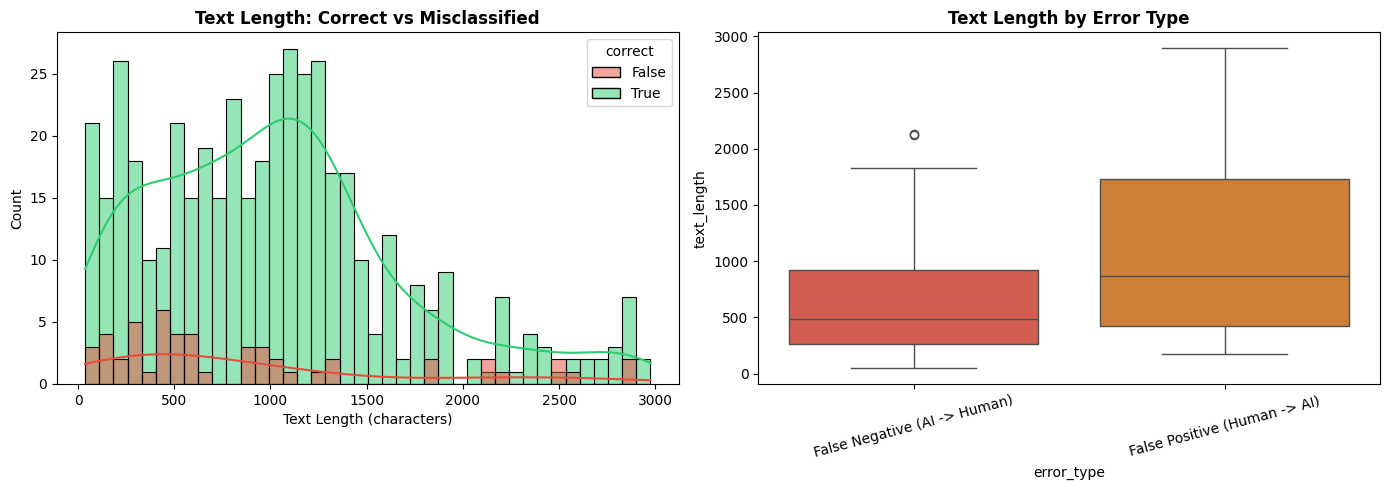


High-confidence errors (>0.75): 0
Series([], Name: count, dtype: int64)


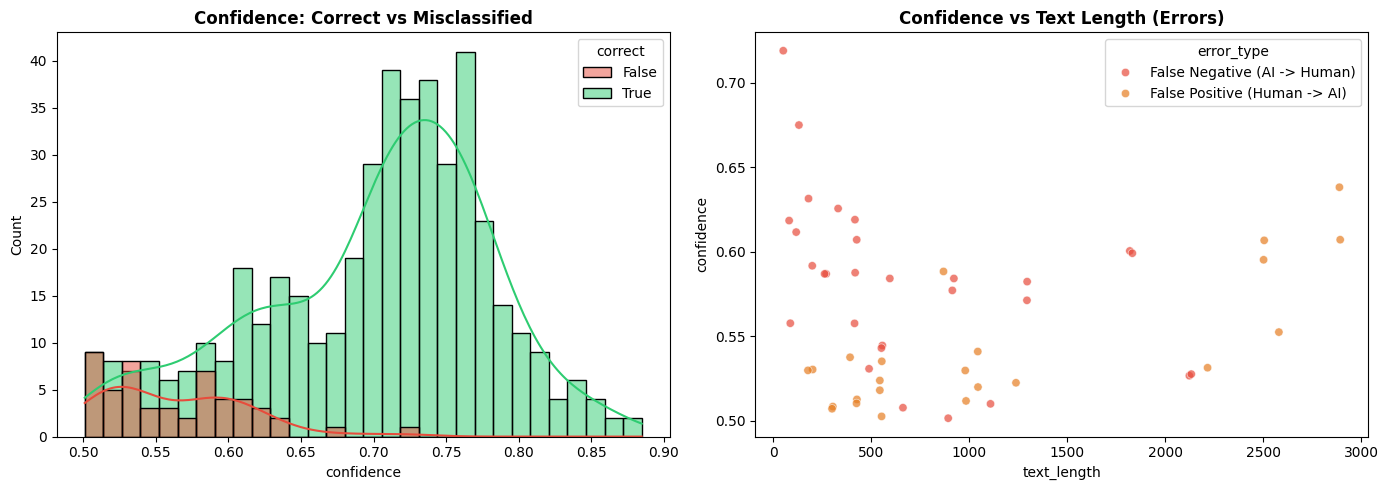

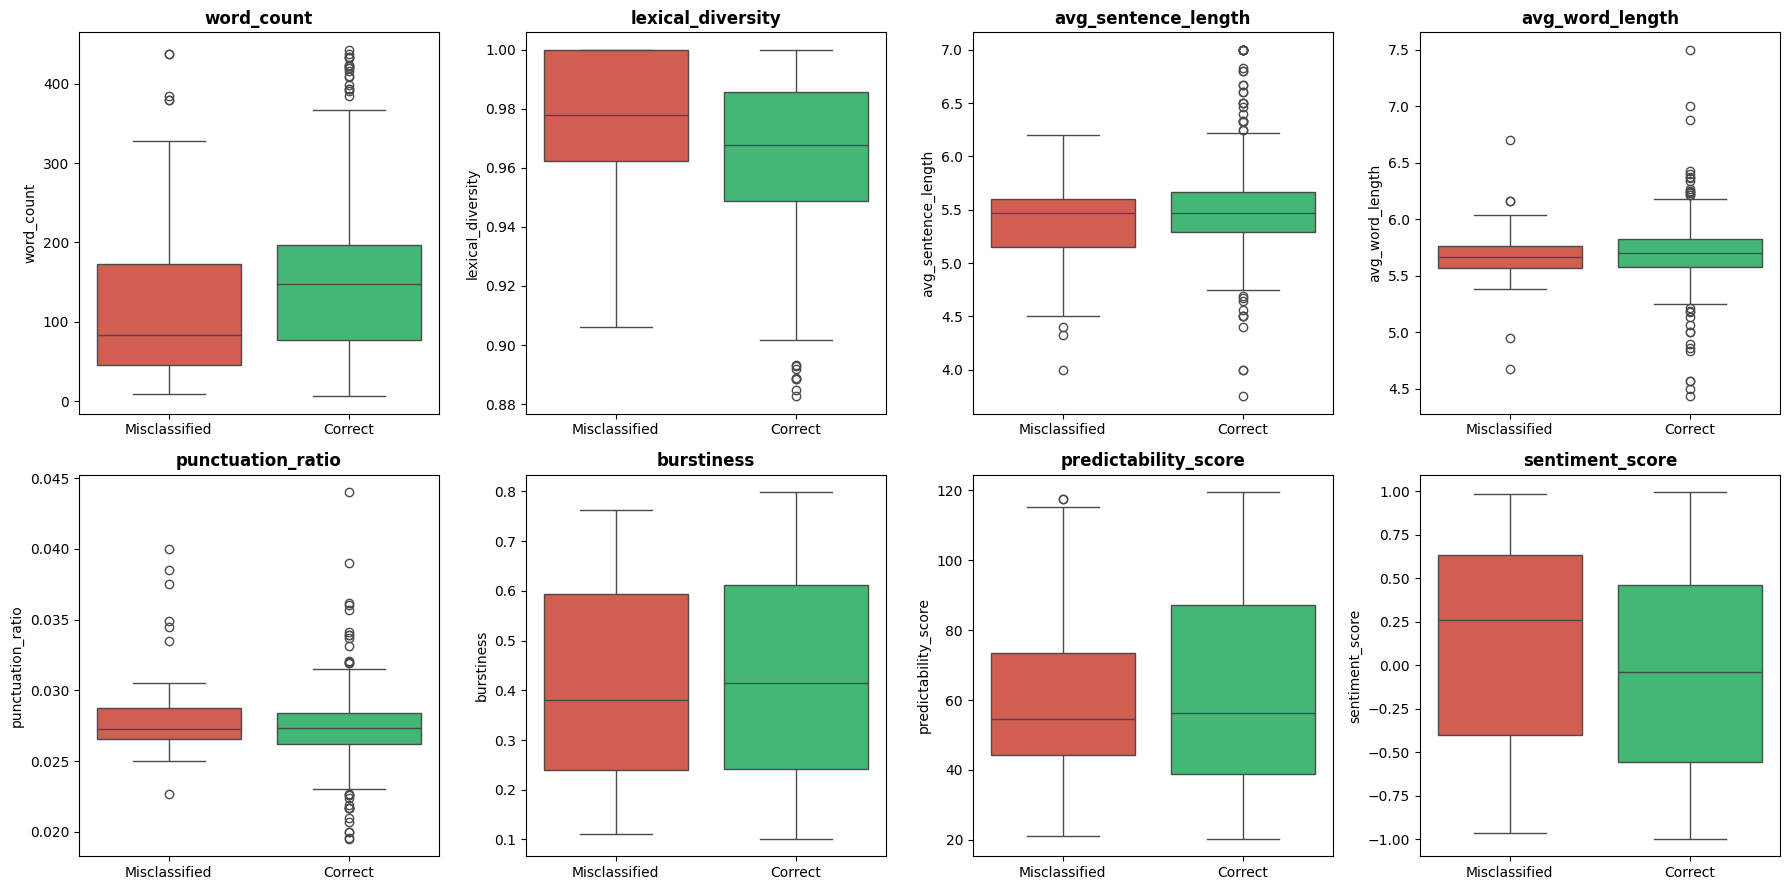


HIGH-CONFIDENCE ERRORS
[1] False Negative (AI -> Human) | conf=0.719 | type=social_media
     True: AI -> Pred: Human
     Text: "Treat against draw oil know. Claim give argue war...."

[2] False Negative (AI -> Human) | conf=0.675 | type=social_media
     True: AI -> Pred: Human
     Text: "Pm turn analysis reduce. Southern among son sort. House woman local unit. Free star the least color. Thank war wall condition sea...."

[3] False Positive (Human -> AI) | conf=0.638 | type=academic_paper
     True: Human -> Pred: AI
     Text: "Wind team reason look sign I. Enter model at least water. Across pretty capital generation. Course month commercial. Walk visit next after message sit. Their produce table ask. Teacher develop toward energy him choose one. Cold school computer moment mouth public. Time continue southern author trial..."

[4] False Negative (AI -> Human) | conf=0.631 | type=blog_post
     True: AI -> Pred: Human
     Text: "Education tax agent court. Mr lead suggest identify

In [ ]:
# PART 7: DEEP ERROR ANALYSIS (fixed flow)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

best_model  = ultimate_best["Model"]
y_pred_best = np.asarray(ultimate_best["Predictions"])
y_true_best = np.asarray(y_test_sr)

# Rebuild test rows using explicit indices to guarantee alignment
all_idx = np.arange(len(augmented_df_sr))
_, test_idx = train_test_split(
    all_idx,
    test_size=0.2,
    random_state=42,
    stratify=augmented_df_sr["label"]
)
test_df_sr = augmented_df_sr.iloc[test_idx].reset_index(drop=True).copy()

if len(test_df_sr) != len(y_pred_best) or len(test_df_sr) != len(y_true_best):
    raise ValueError(
        f"Length mismatch: test_df={len(test_df_sr)}, y_true={len(y_true_best)}, y_pred={len(y_pred_best)}"
    )

test_df_sr["y_true"] = y_true_best
test_df_sr["y_pred"] = y_pred_best
test_df_sr["correct"] = test_df_sr["y_true"] == test_df_sr["y_pred"]

# Confidence
if hasattr(best_model, "predict_proba"):
    proba = best_model.predict_proba(X_test_sr)
    test_df_sr["confidence"] = proba.max(axis=1)
else:
    decision = best_model.decision_function(X_test_sr)
    denom = np.max(np.abs(decision)) if np.max(np.abs(decision)) != 0 else 1.0
    test_df_sr["confidence"] = np.abs(decision) / denom

def error_type(row):
    if row["correct"]:
        return "Correct"
    if row["y_true"] == 0 and row["y_pred"] == 1:
        return "False Positive (Human -> AI)"
    return "False Negative (AI -> Human)"

test_df_sr["error_type"] = test_df_sr.apply(error_type, axis=1)

# Safety dedup pass
before = len(test_df_sr)
test_df_sr["text_normalised"] = test_df_sr["text_content"].astype(str).str.lower().str.strip()
test_df_sr = test_df_sr.drop_duplicates(subset="text_normalised").reset_index(drop=True)
after = len(test_df_sr)

print(f"Safety dedup removed: {before - after}")
print(f"Total test samples (clean): {after}")

# Text length + errors
test_df_sr["text_length"] = test_df_sr["text_content"].astype(str).apply(len)
errors_df = test_df_sr[~test_df_sr["correct"]].copy()

print(f"\nCorrect: {test_df_sr['correct'].sum()}  |  Misclassified: {len(errors_df)}")
if len(test_df_sr) > 0:
    print(f"Accuracy (deduped): {test_df_sr['correct'].mean():.1%}")
print(errors_df["error_type"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=test_df_sr, x="text_length", hue="correct", bins=40, kde=True,
    palette={True: "#2ecc71", False: "#e74c3c"}, ax=axes[0]
)
axes[0].set_title("Text Length: Correct vs Misclassified", fontweight="bold")
axes[0].set_xlabel("Text Length (characters)")

sns.boxplot(
    data=test_df_sr[test_df_sr["error_type"] != "Correct"],
    x="error_type", y="text_length",
    palette=["#e74c3c", "#e67e22"], ax=axes[1]
)
axes[1].set_title("Text Length by Error Type", fontweight="bold")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

# Confidence analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=test_df_sr, x="confidence", hue="correct", bins=30, kde=True,
    palette={True: "#2ecc71", False: "#e74c3c"}, ax=axes[0]
)
axes[0].set_title("Confidence: Correct vs Misclassified", fontweight="bold")

high_conf_errors = errors_df[errors_df["confidence"] > 0.75]
print(f"\nHigh-confidence errors (>0.75): {len(high_conf_errors)}")
print(high_conf_errors["error_type"].value_counts())

if len(errors_df) > 0:
    sns.scatterplot(
        data=errors_df, x="text_length", y="confidence", hue="error_type",
        palette=["#e74c3c", "#e67e22"], alpha=0.7, ax=axes[1]
    )
axes[1].set_title("Confidence vs Text Length (Errors)", fontweight="bold")
plt.tight_layout()
plt.show()

# Numeric-feature error comparison
numeric_cols = [
    "word_count", "lexical_diversity", "avg_sentence_length", "avg_word_length",
    "punctuation_ratio", "burstiness", "predictability_score", "sentiment_score"
]
available_cols = [c for c in numeric_cols if c in test_df_sr.columns]

# Force consistent string labels for plotting
plot_df = test_df_sr.copy()
plot_df["correct_label"] = plot_df["correct"].astype(str)  # "False", "True"

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(available_cols[:len(axes)]):
    sns.boxplot(
        data=plot_df,
        x="correct_label",
        y=col,
        order=["False", "True"],
        palette={"False": "#e74c3c", "True": "#2ecc71"},
        ax=axes[i]
    )
    axes[i].set_title(col, fontweight="bold")
    axes[i].set_xticklabels(["Misclassified", "Correct"])
    axes[i].set_xlabel("")

for j in range(len(available_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


# Qualitative top errors
print("\n" + "=" * 70)
print("HIGH-CONFIDENCE ERRORS")
print("=" * 70)

top_cols = ["text_content", "y_true", "y_pred", "confidence", "error_type"]
if "content_type" in errors_df.columns:
    top_cols.append("content_type")

top_errors = errors_df.nlargest(10, "confidence")[top_cols].reset_index(drop=True)
label_map = {0: "Human", 1: "AI"}

for i, row in top_errors.iterrows():
    ctype = row["content_type"] if "content_type" in row else "N/A"
    print(f"[{i+1}] {row['error_type']} | conf={row['confidence']:.3f} | type={ctype}")
    print(f"     True: {label_map[row['y_true']]} -> Pred: {label_map[row['y_pred']]}")
    print(f"     Text: \"{str(row['text_content'])[:300].replace(chr(10), ' ')}...\"")
    print()


In [ ]:
# PART 8a: RECOVER REAL FEATURE NAMES FOR SHAP (aligned with SR training pipeline)

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2

print("Rebuilding feature space with same settings as SR training...")

df_sr_temp = augmented_df_sr.copy()

# 1) Intrinsic/base numeric features in exact dataframe order
drop_cols = ["label", "text_content"]
if "content_type" in df_sr_temp.columns:
    drop_cols.append("content_type")

X_numeric_sr = df_sr_temp.drop(columns=drop_cols, errors="ignore")
num_cols = X_numeric_sr.select_dtypes(include=["int64", "float64"]).columns
X_numeric_sr[num_cols] = X_numeric_sr[num_cols].fillna(X_numeric_sr[num_cols].median())

# 2) Advanced features (same extractor)
text_feats_sr = pd.DataFrame(list(df_sr_temp["text_content"].apply(extract_advanced_features)))

# 3) content_type dummies (optional)
if "content_type" in df_sr_temp.columns:
    ct_dummies_sr = pd.get_dummies(df_sr_temp["content_type"], prefix="content", drop_first=True)
else:
    ct_dummies_sr = pd.DataFrame(index=df_sr_temp.index)

# Numeric + engineered block
X_numeric_combined_sr = pd.concat([X_numeric_sr, text_feats_sr, ct_dummies_sr], axis=1)
group1_names = X_numeric_combined_sr.columns.tolist()

# 4) TF-IDF word ngrams (MATCH SR preprocess settings)
tfidf_temp = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1, 3),
    min_df=3,
    max_df=0.85,
    strip_accents="unicode",
    lowercase=True,
    sublinear_tf=True,
    stop_words="english"
)
X_tfidf_sr = tfidf_temp.fit_transform(df_sr_temp["text_content"]).toarray()
group2_names = [f"tfidf:{n}" for n in tfidf_temp.get_feature_names_out()]

# 5) Char ngrams (MATCH SR preprocess settings)
char_temp = TfidfVectorizer(analyzer="char", ngram_range=(2, 4), max_features=500)
X_char_sr = char_temp.fit_transform(df_sr_temp["text_content"]).toarray()
group3_names = [f"char:{n}" for n in char_temp.get_feature_names_out()]

# Full matrix + names
X_all_sr = np.hstack([X_numeric_combined_sr.values, X_tfidf_sr, X_char_sr])
all_feature_names_full = group1_names + group2_names + group3_names

print(f"Pre-selection shape: {X_all_sr.shape}")
print(f"Feature-name count : {len(all_feature_names_full)}")

# 6) SelectKBest mask (MATCH k used in SR training)
selector_temp = SelectKBest(chi2, k=min(800, X_all_sr.shape[1]))
selector_temp.fit(np.abs(X_all_sr), df_sr_temp["label"])

selected_mask = selector_temp.get_support()
real_feat_names = np.array(all_feature_names_full)[selected_mask].tolist()

print(f"Selected feature count: {len(real_feat_names)}")
print("Top 10 selected names:")
for i, n in enumerate(real_feat_names[:10], 1):
    print(f"{i:2d}. {n}")

# SHAP will use this
feature_names = real_feat_names
print("\nfeature_names updated.")


Rebuilding feature space with same settings as SR training...
Pre-selection shape: (2519, 2537)
Feature-name count : 2537
Selected feature count: 800
Top 10 selected names:
 1. word_count
 2. character_count
 3. sentence_count
 4. flesch_reading_ease
 5. gunning_fog_index
 6. predictability_score
 7. burstiness
 8. sentiment_score
 9. num_sentences
10. word_diversity

feature_names updated.


feature_names loaded: 800 features
Sample: ['word_count', 'character_count', 'sentence_count', 'flesch_reading_ease', 'gunning_fog_index']

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Computing SHAP values for 504 samples...


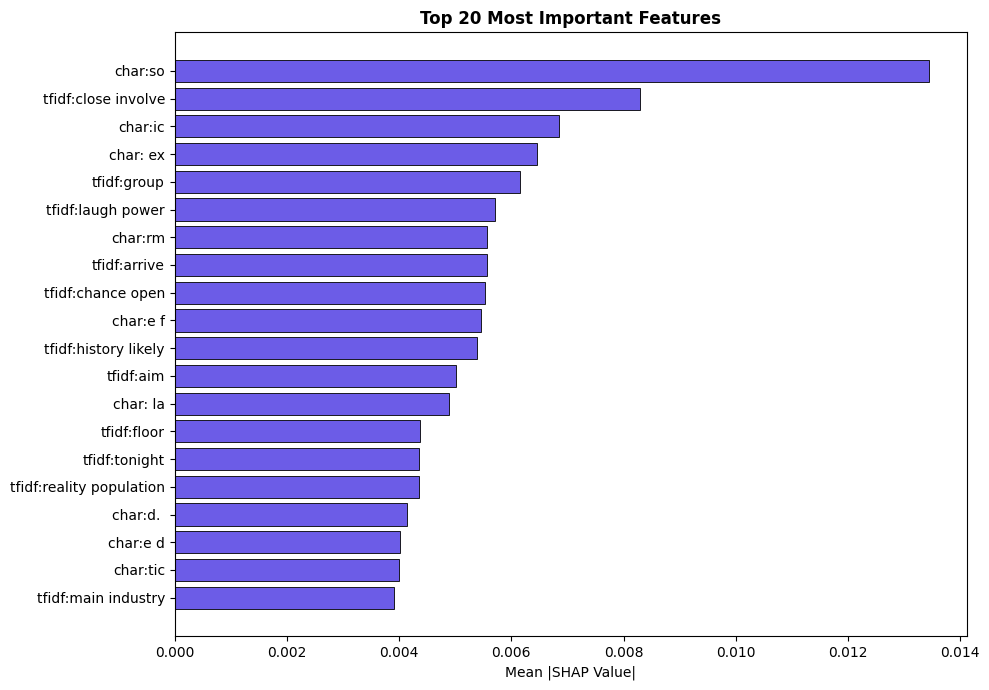

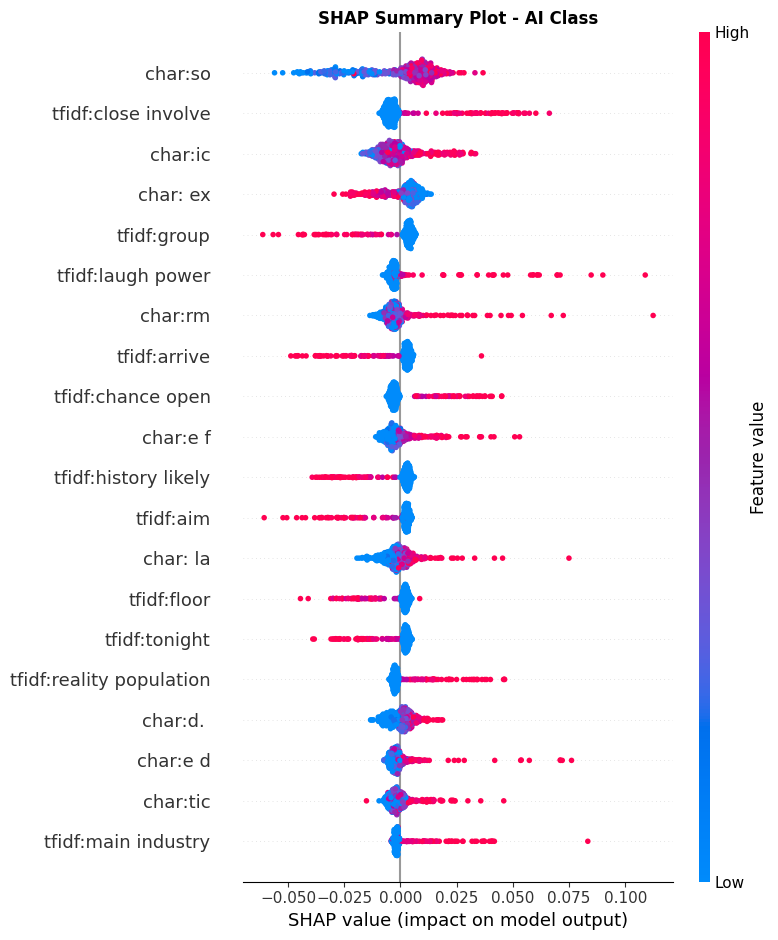

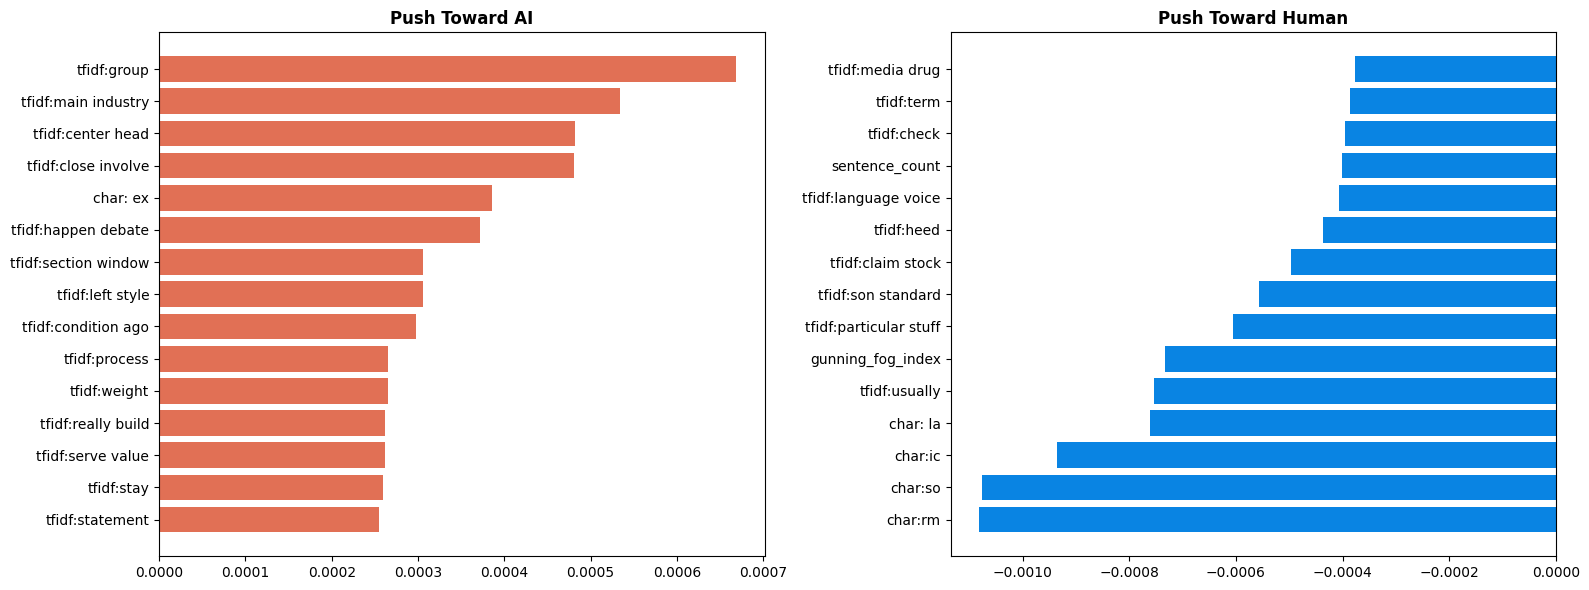

FN 1: idx=146, conf(Human)=0.719


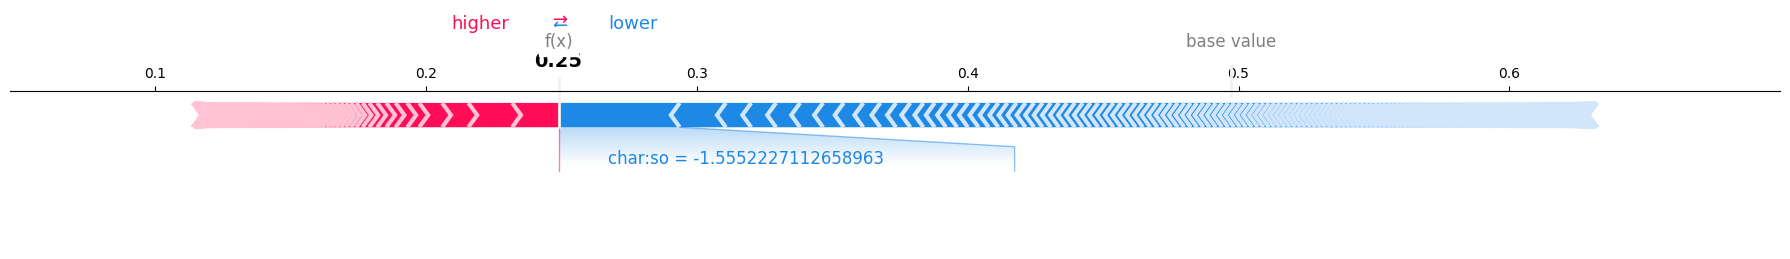

FN 2: idx=113, conf(Human)=0.675


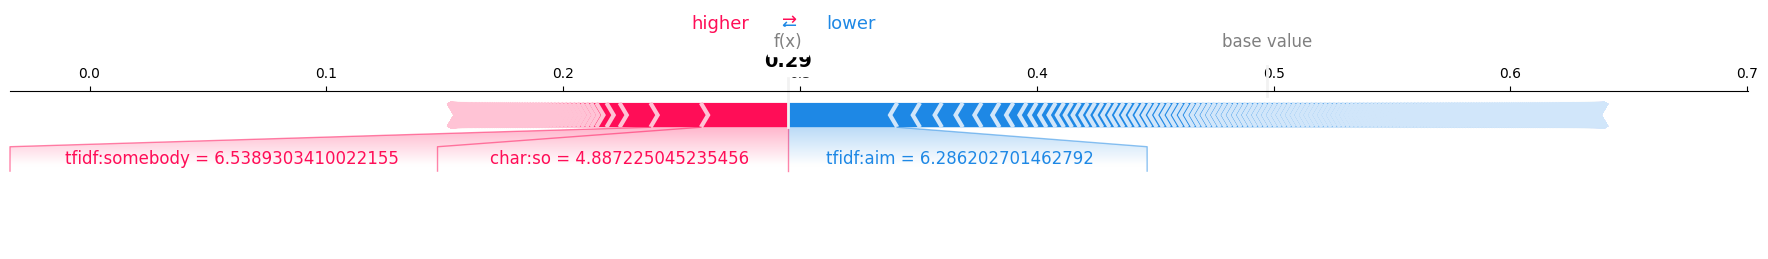

FN 3: idx=292, conf(Human)=0.631


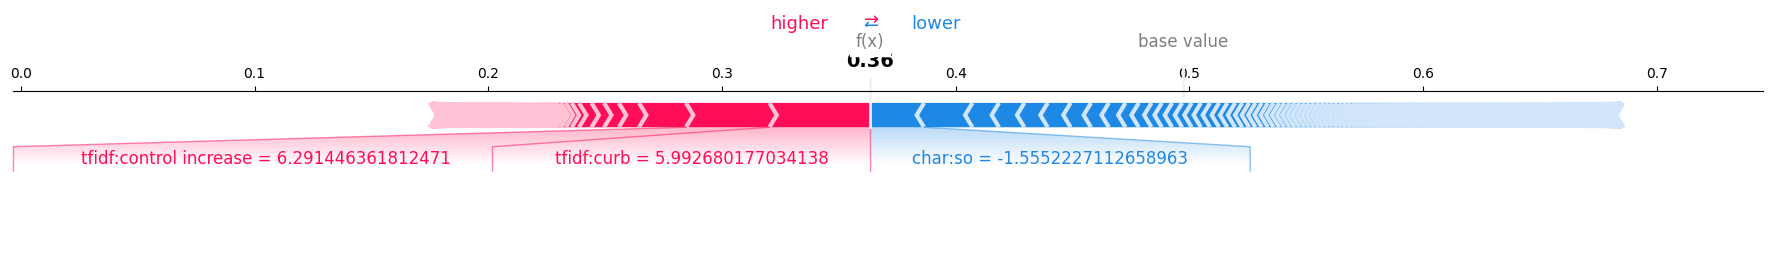

FP 1: idx=188, conf(AI)=0.638


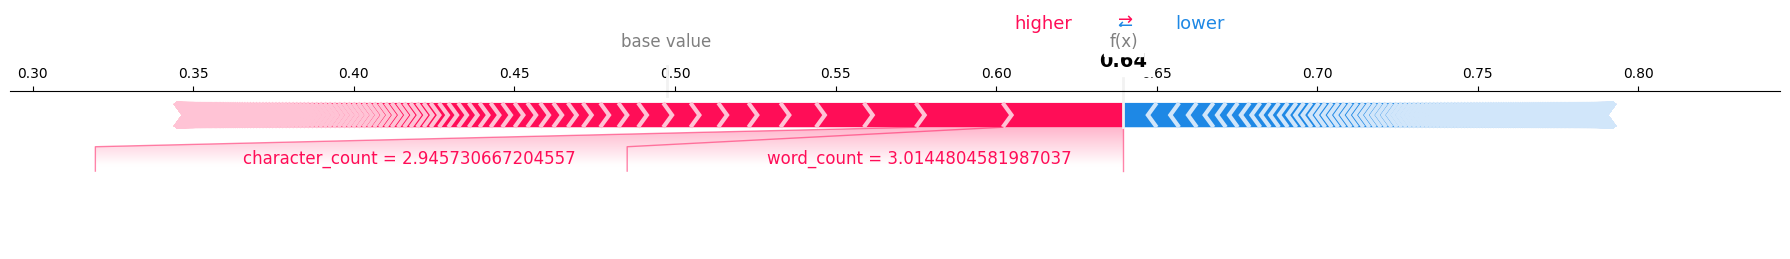

FP 2: idx=30, conf(AI)=0.607


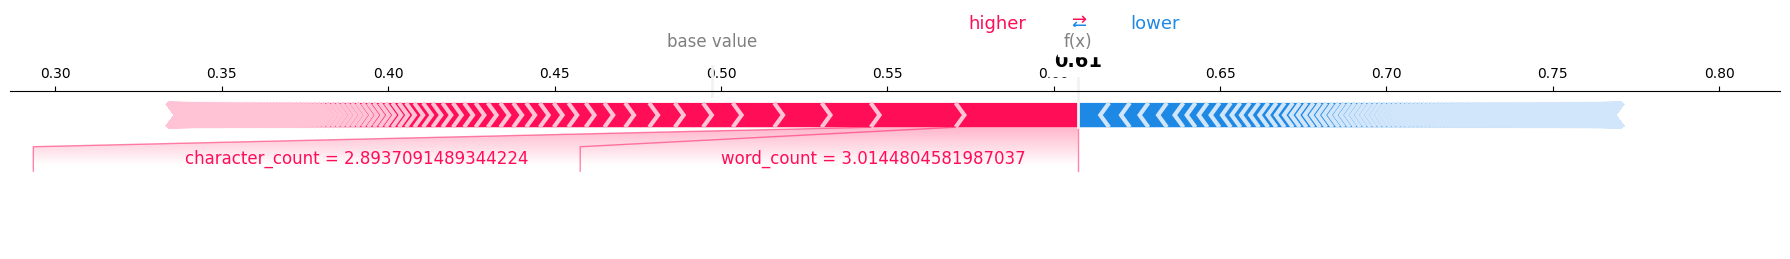

FP 3: idx=150, conf(AI)=0.607


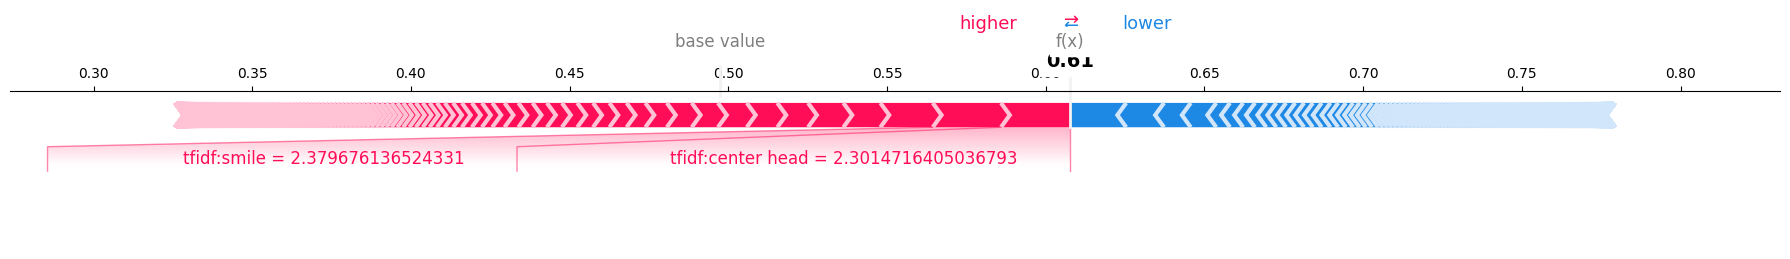

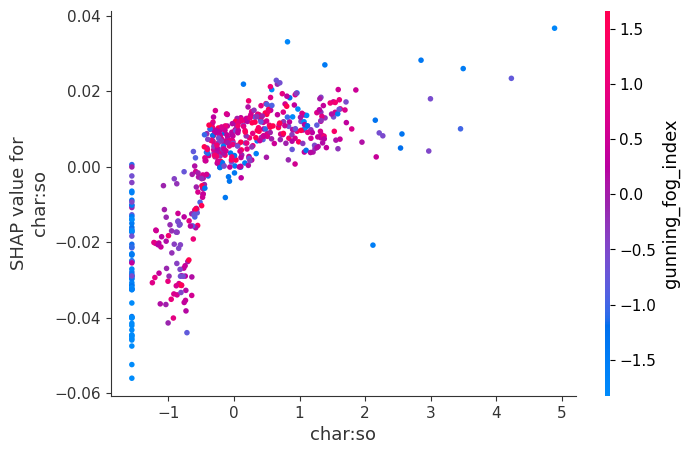

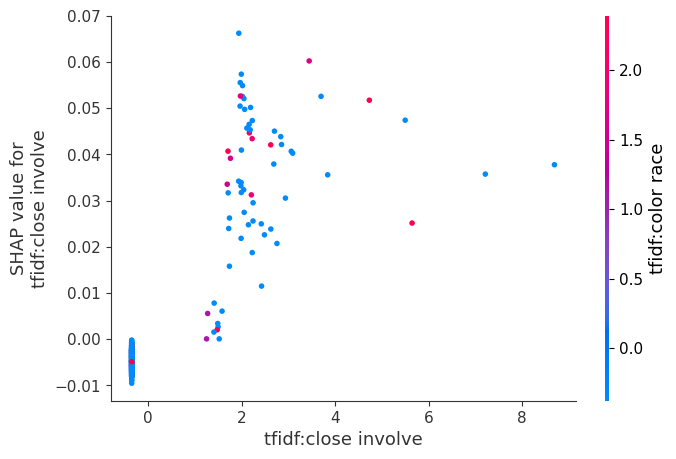

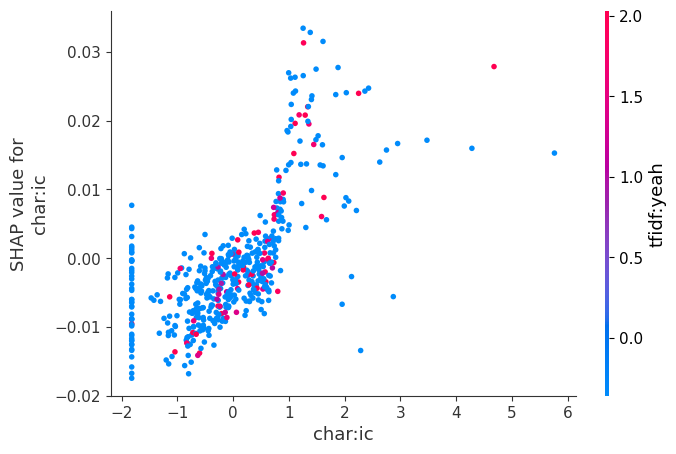

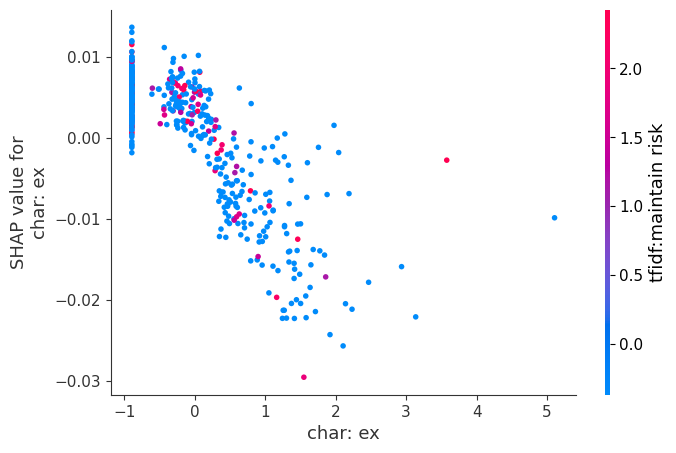

SHAP completed successfully.


In [ ]:
# Confirm real feature names are loaded before running SHAP plots
print(f"feature_names loaded: {len(feature_names)} features")
print(f"Sample: {feature_names[:5]}")

# PART 8: SHAP EXPLAINABILITY
import sys
!{sys.executable} -m pip install --quiet shap

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rf_model = best_rf_opt["Model"]
X_explain = X_test_sr
y_explain = np.asarray(y_test_sr)

if len(feature_names) != X_explain.shape[1]:
    raise ValueError(f"feature_names={len(feature_names)} but X_explain has {X_explain.shape[1]} features. Re-run Part 8a.")

print(f"Computing SHAP values for {X_explain.shape[0]} samples...")

explainer = shap.TreeExplainer(rf_model, feature_perturbation="interventional")
raw = explainer.shap_values(X_explain, check_additivity=False)

def get_shap_ai(raw_vals):
    # Handles SHAP outputs across versions
    if hasattr(raw_vals, "values"):  # Explanation object
        vals = raw_vals.values
        if vals.ndim == 3:   # (n_samples, n_features, n_classes)
            return vals[:, :, 1]
        if vals.ndim == 2:
            return vals
    if isinstance(raw_vals, list):   # old API: [class0, class1]
        return raw_vals[1]
    if isinstance(raw_vals, np.ndarray):
        if raw_vals.ndim == 3:
            return raw_vals[:, :, 1]
        if raw_vals.ndim == 2:
            return raw_vals
    raise ValueError(f"Unsupported SHAP output format: {type(raw_vals)}")

shap_ai = get_shap_ai(raw)
if shap_ai.shape != X_explain.shape:
    raise ValueError(f"SHAP shape mismatch: {shap_ai.shape} vs {X_explain.shape}")

# 1) Global importance
mean_abs_shap = np.abs(shap_ai).mean(axis=0)
top_n = 20
top_idx = np.argsort(mean_abs_shap)[::-1][:top_n]
top_names = [feature_names[i] for i in top_idx]
top_vals = mean_abs_shap[top_idx]

plt.figure(figsize=(10, 7))
plt.barh(top_names[::-1], top_vals[::-1], color="#6c5ce7", edgecolor="black", linewidth=0.6)
plt.xlabel("Mean |SHAP Value|")
plt.title(f"Top {top_n} Most Important Features", fontweight="bold")
plt.tight_layout()
plt.show()

# 2) Summary beeswarm
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_ai, X_explain, feature_names=feature_names, max_display=20, show=False)
plt.title("SHAP Summary Plot - AI Class", fontweight="bold")
plt.tight_layout()
plt.show()

# 3) Directional comparison
mean_shap_ai = shap_ai.mean(axis=0)
ai_drivers = np.argsort(mean_shap_ai)[::-1][:15]
human_drivers = np.argsort(mean_shap_ai)[:15]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh([feature_names[i] for i in ai_drivers][::-1], [mean_shap_ai[i] for i in ai_drivers][::-1], color="#e17055")
axes[0].set_title("Push Toward AI", fontweight="bold")
axes[1].barh([feature_names[i] for i in human_drivers], [mean_shap_ai[i] for i in human_drivers], color="#0984e3")
axes[1].set_title("Push Toward Human", fontweight="bold")
plt.tight_layout()
plt.show()

# 4) Force plots (safe if no FN/FP)
y_pred_all = rf_model.predict(X_test_sr)
proba_all = rf_model.predict_proba(X_test_sr)

fn_idx = np.where((y_explain == 1) & (y_pred_all == 0))[0]
fp_idx = np.where((y_explain == 0) & (y_pred_all == 1))[0]

top_fn = fn_idx[np.argsort(proba_all[fn_idx, 0])[::-1][:3]] if len(fn_idx) else []
top_fp = fp_idx[np.argsort(proba_all[fp_idx, 1])[::-1][:3]] if len(fp_idx) else []

ev = explainer.expected_value
ev_ai = ev[1] if isinstance(ev, (list, np.ndarray)) else ev

shap.initjs()

for i, idx in enumerate(top_fn):
    print(f"FN {i+1}: idx={idx}, conf(Human)={proba_all[idx,0]:.3f}")
    shap.force_plot(ev_ai, shap_ai[idx], X_explain[idx], feature_names=feature_names, matplotlib=True, show=False, figsize=(18, 3))
    plt.tight_layout()
    plt.show()

for i, idx in enumerate(top_fp):
    print(f"FP {i+1}: idx={idx}, conf(AI)={proba_all[idx,1]:.3f}")
    shap.force_plot(ev_ai, shap_ai[idx], X_explain[idx], feature_names=feature_names, matplotlib=True, show=False, figsize=(18, 3))
    plt.tight_layout()
    plt.show()

# 5) Dependence plots
for feat_idx in top_idx[:4]:
    shap.dependence_plot(feat_idx, shap_ai, X_explain, feature_names=feature_names, show=True)

print("SHAP completed successfully.")


In [ ]:
# Install LIME
import sys
!{sys.executable} -m pip install --quiet lime

import lime
import lime.lime_text
import numpy as np
import pandas as pd
import re
import warnings
warnings.filterwarnings("ignore")

# Best RF model
rf_model = best_rf_opt["Model"]

# --- Rebuild exact schema used before SelectKBest ---
base_numeric_cols = augmented_df_sr.drop(
    columns=["label", "text_content", "content_type"], errors="ignore"
).columns.tolist()

advanced_feature_cols = [
    "sentiment_polarity", "sentiment_subjectivity", "num_sentences",
    "avg_word_length", "unique_word_ratio", "stopword_ratio",
    "uppercase_ratio", "digit_ratio", "special_char_ratio",
    "avg_sentence_length", "long_word_ratio", "question_count",
    "exclamation_count", "comma_ratio", "semicolon_ratio", "word_diversity"
]

ct_cols = (
    pd.get_dummies(augmented_df_sr["content_type"], prefix="content", drop_first=True).columns.tolist()
    if "content_type" in augmented_df_sr.columns else []
)

def calculate_intrinsic_features_for_infer(text):
    text = "" if text is None else str(text)
    words = re.findall(r"\b\w+\b", text.lower())
    num_w = len(words)
    num_c = len(text.replace(" ", ""))
    sentences = [s for s in re.split(r"[.!?]\s*", text) if s.strip()]
    num_s = len(sentences)

    return {
        "word_count": num_w,
        "character_count": num_c,
        "sentence_count": num_s,
        "lexical_diversity": (len(set(words)) / num_w) if num_w else 0,
        "avg_sentence_length": (num_w / num_s) if num_s else 0,
        "avg_word_length": (sum(len(w) for w in words) / num_w) if num_w else 0,
        "punctuation_ratio": (sum(1 for c in text if c in ".,;!?") / num_c) if num_c else 0,
        "flesch_reading_ease": 0,
        "gunning_fog_index": 0,
        "grammar_errors": 0,
        "passive_voice_ratio": 0,
        "predictability_score": 0,
        "burstiness": 0,
        "sentiment_score": 0,
    }

def text_to_features(texts):
    rows = []
    for t in texts:
        t = "" if t is None else str(t)

        intrinsic = calculate_intrinsic_features_for_infer(t)
        adv = extract_advanced_features(t)

        row = {}
        # base numeric block in exact column order
        for c in base_numeric_cols:
            row[c] = intrinsic.get(c, 0)

        # advanced block
        for c in advanced_feature_cols:
            row[c] = adv.get(c, 0)

        # content_type dummies unknown at inference => zeros
        for c in ct_cols:
            row[c] = 0

        rows.append(row)

    X_group1 = pd.DataFrame(rows, columns=base_numeric_cols + advanced_feature_cols + ct_cols).fillna(0).values
    X_tfidf = tfidf_temp.transform([str(t) for t in texts]).toarray()
    X_char = char_temp.transform([str(t) for t in texts]).toarray()

    X_all = np.hstack([X_group1, X_tfidf, X_char])
    X_selected = selector_temp.transform(np.abs(X_all))

    if hasattr(rf_model, "n_features_in_") and X_selected.shape[1] != rf_model.n_features_in_:
        raise ValueError(
            f"LIME pipeline mismatch: built {X_selected.shape[1]} features, model expects {rf_model.n_features_in_}"
        )

    return X_selected

def predict_proba_text(texts):
    return rf_model.predict_proba(text_to_features(texts))

# quick test
sample_text = str(augmented_df_sr["text_content"].iloc[0])
proba = predict_proba_text([sample_text])[0]
print(f"P(Human)={proba[0]:.3f}, P(AI)={proba[1]:.3f}")
print("LIME wrapper ready.")



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
P(Human)=0.577, P(AI)=0.423
LIME wrapper ready.



  PASS 1 - Correct AI Prediction (High Confidence)
  True: AI  |  Predicted: AI  |  Confidence: 0.852
  Text (first 300 chars): Collection prove lawyer that recent. Arrive half prevent off key.
Kid serve next law some dinner hold....



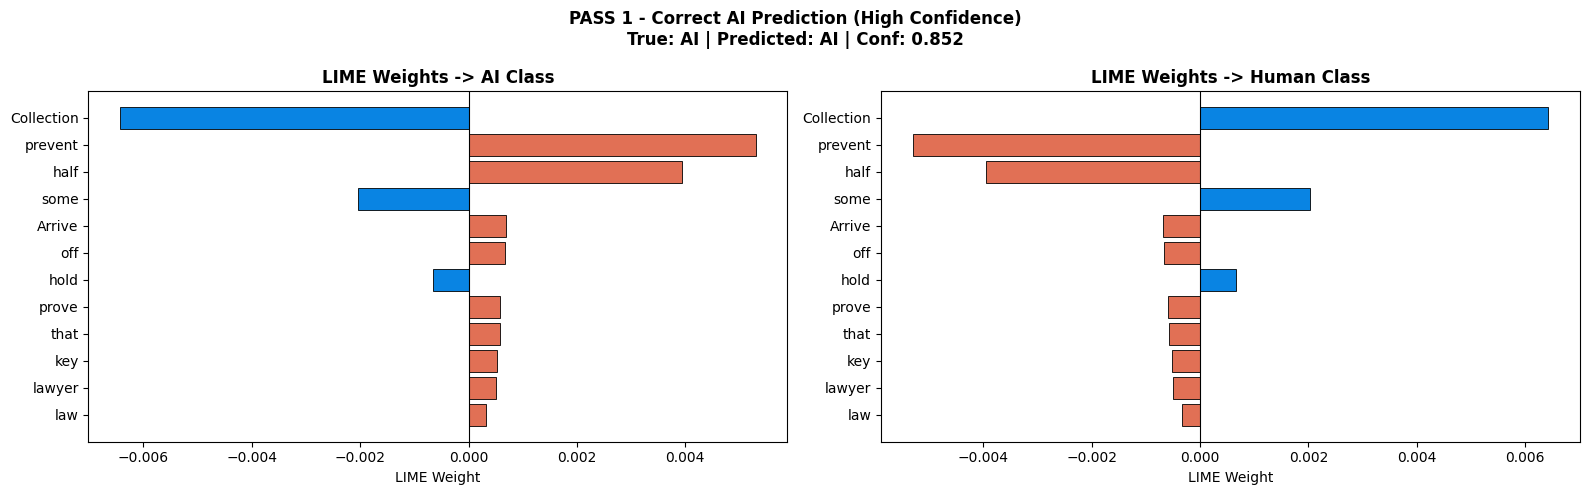

  Top words pushing -> AI:
    prevent               +0.0053  -> AI
    half                  +0.0039  -> AI
    Arrive                +0.0007  -> AI
    off                   +0.0007  -> AI
    prove                 +0.0006  -> AI
    that                  +0.0006  -> AI

  Top words pushing -> Human:
    Collection            +0.0064  -> Human
    some                  +0.0020  -> Human
    hold                  +0.0007  -> Human
    law                   -0.0003  -> AI
    lawyer                -0.0005  -> AI
    key                   -0.0005  -> AI

  PASS 2 - Correct Human Prediction (High Confidence)
  True: Human  |  Predicted: Human  |  Confidence: 0.885
  Text (first 300 chars): Worker opportunity positive peace without himself....



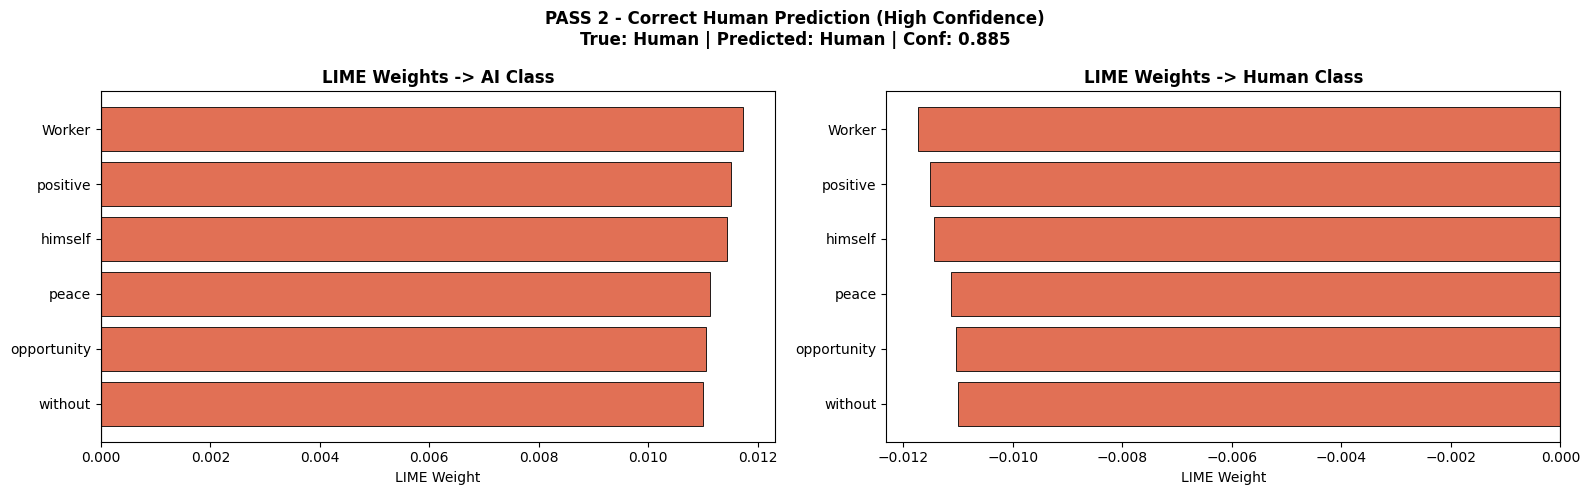

  Top words pushing -> AI:
    Worker                +0.0117  -> AI
    positive              +0.0115  -> AI
    himself               +0.0114  -> AI
    peace                 +0.0111  -> AI
    opportunity           +0.0110  -> AI
    without               +0.0110  -> AI

  Top words pushing -> Human:
    without               -0.0110  -> AI
    opportunity           -0.0110  -> AI
    peace                 -0.0111  -> AI
    himself               -0.0114  -> AI
    positive              -0.0115  -> AI
    Worker                -0.0117  -> AI

  PASS 3 - False Negative #1 (AI predicted as Human)
  True: AI  |  Predicted: Human  |  Confidence: 0.719
  Text (first 300 chars): Treat against draw oil know. Claim give argue war....



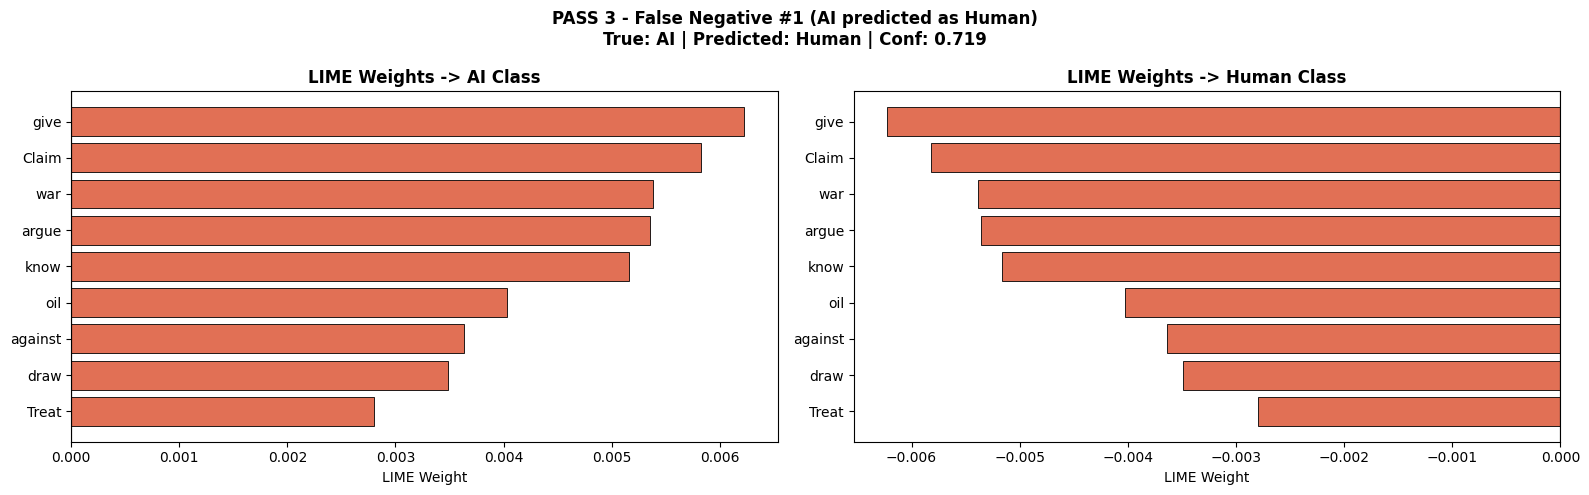

  Top words pushing -> AI:
    give                  +0.0062  -> AI
    Claim                 +0.0058  -> AI
    war                   +0.0054  -> AI
    argue                 +0.0054  -> AI
    know                  +0.0052  -> AI
    oil                   +0.0040  -> AI

  Top words pushing -> Human:
    Treat                 -0.0028  -> AI
    draw                  -0.0035  -> AI
    against               -0.0036  -> AI
    oil                   -0.0040  -> AI
    know                  -0.0052  -> AI
    argue                 -0.0054  -> AI

  PASS 4 - False Negative #2 (AI predicted as Human)
  True: AI  |  Predicted: Human  |  Confidence: 0.675
  Text (first 300 chars): Pm turn analysis reduce. Southern among son sort.
House woman local unit. Free star the least color. Thank war wall condition sea....



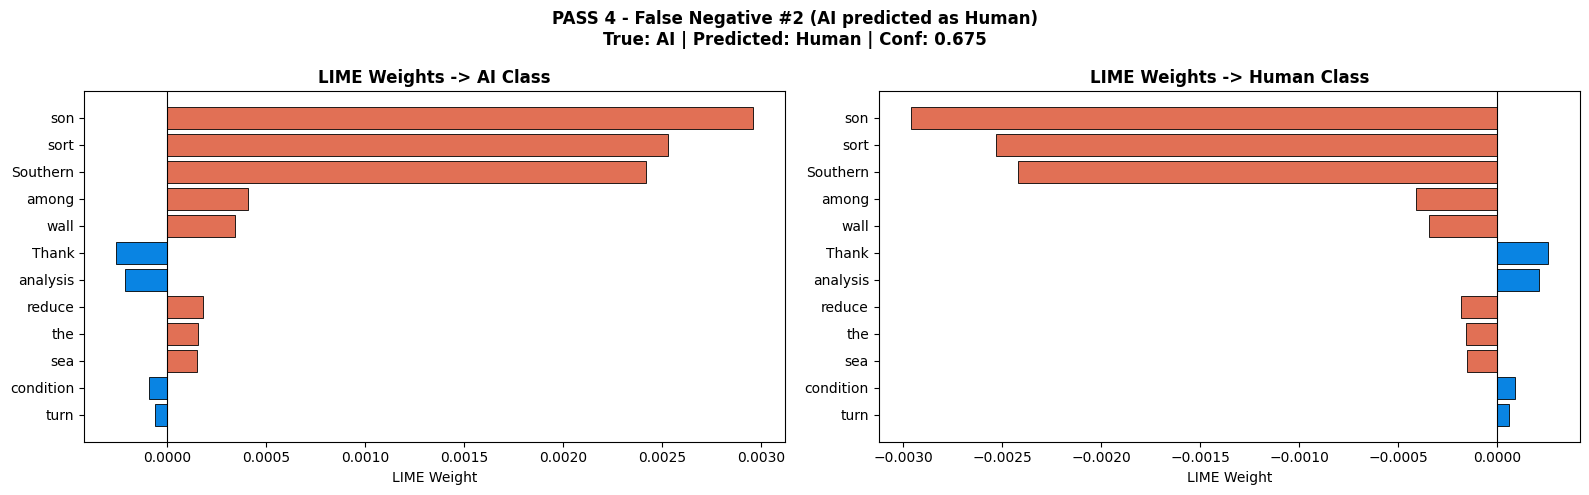

  Top words pushing -> AI:
    son                   +0.0030  -> AI
    sort                  +0.0025  -> AI
    Southern              +0.0024  -> AI
    among                 +0.0004  -> AI
    wall                  +0.0003  -> AI
    reduce                +0.0002  -> AI

  Top words pushing -> Human:
    Thank                 +0.0003  -> Human
    analysis              +0.0002  -> Human
    condition             +0.0001  -> Human
    turn                  +0.0001  -> Human
    sea                   -0.0002  -> AI
    the                   -0.0002  -> AI


In [ ]:
# PART 9b: LIME EXPLAINABILITY — Four Analysis Passes (robust)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lime.lime_text
from sklearn.model_selection import train_test_split

explainer_lime = lime.lime_text.LimeTextExplainer(
    class_names=["Human", "AI"],
    random_state=42
)

label_map = {0: "Human", 1: "AI"}

def run_lime(text, true_label, pred_label, confidence, title, num_features=12):
    print(f"\n{'='*70}")
    print(f"  {title}")
    print(f"  True: {label_map[int(true_label)]}  |  Predicted: {label_map[int(pred_label)]}  |  Confidence: {confidence:.3f}")
    print(f"{'='*70}")
    print(f"  Text (first 300 chars): {str(text)[:300]}...\n")

    exp = explainer_lime.explain_instance(
        str(text),
        predict_proba_text,
        num_features=num_features,
        num_samples=500,
        labels=[0, 1]
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for class_idx, class_name, ax, color_pos, color_neg in [
        (1, "AI",    axes[0], "#e17055", "#0984e3"),
        (0, "Human", axes[1], "#0984e3", "#e17055"),
    ]:
        ww = exp.as_list(label=class_idx)
        words = [w for w, _ in ww]
        weights = [v for _, v in ww]
        colors = [color_pos if v > 0 else color_neg for v in weights]

        ax.barh(words[::-1], weights[::-1], color=colors[::-1], edgecolor="black", linewidth=0.6)
        ax.axvline(x=0, color="black", linewidth=0.8)
        ax.set_title(f"LIME Weights -> {class_name} Class", fontweight="bold")
        ax.set_xlabel("LIME Weight")

    plt.suptitle(
        f"{title}\nTrue: {label_map[int(true_label)]} | Predicted: {label_map[int(pred_label)]} | Conf: {confidence:.3f}",
        fontsize=12, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()

    print("  Top words pushing -> AI:")
    for w, v in sorted(exp.as_list(label=1), key=lambda x: x[1], reverse=True)[:6]:
        print(f"    {w:<20s}  {v:+.4f}  {'-> AI' if v > 0 else '-> Human'}")

    print("\n  Top words pushing -> Human:")
    for w, v in sorted(exp.as_list(label=0), key=lambda x: x[1], reverse=True)[:6]:
        print(f"    {w:<20s}  {v:+.4f}  {'-> Human' if v > 0 else '-> AI'}")

    return exp

# --- Recover test rows with guaranteed alignment ---
all_idx = np.arange(len(augmented_df_sr))
_, test_idx = train_test_split(
    all_idx,
    test_size=0.2,
    random_state=42,
    stratify=augmented_df_sr["label"]
)

test_df_lime = augmented_df_sr.iloc[test_idx].reset_index(drop=True).copy()

y_true_all = np.asarray(y_test_sr)
y_pred_all = rf_model.predict(X_test_sr)
proba_all = rf_model.predict_proba(X_test_sr)

if not (len(test_df_lime) == len(y_true_all) == len(y_pred_all)):
    raise ValueError(
        f"Length mismatch: test_df={len(test_df_lime)}, y_true={len(y_true_all)}, y_pred={len(y_pred_all)}"
    )

test_df_lime["y_true"] = y_true_all
test_df_lime["y_pred"] = y_pred_all
test_df_lime["conf_ai"] = proba_all[:, 1]
test_df_lime["conf_human"] = proba_all[:, 0]
test_df_lime["correct"] = test_df_lime["y_true"] == test_df_lime["y_pred"]

# PASS 1
cand_ai = test_df_lime[(test_df_lime["correct"]) & (test_df_lime["y_true"] == 1)].nlargest(1, "conf_ai")
if len(cand_ai):
    row = cand_ai.iloc[0]
    exp1 = run_lime(row["text_content"], 1, 1, row["conf_ai"], "PASS 1 - Correct AI Prediction (High Confidence)")
else:
    print("PASS 1 skipped: no correct AI sample found.")

# PASS 2
cand_h = test_df_lime[(test_df_lime["correct"]) & (test_df_lime["y_true"] == 0)].nlargest(1, "conf_human")
if len(cand_h):
    row = cand_h.iloc[0]
    exp2 = run_lime(row["text_content"], 0, 0, row["conf_human"], "PASS 2 - Correct Human Prediction (High Confidence)")
else:
    print("PASS 2 skipped: no correct Human sample found.")

# PASS 3 & 4
test_df_lime["text_norm"] = test_df_lime["text_content"].astype(str).str.lower().str.strip()
test_df_dedup = test_df_lime.drop_duplicates(subset="text_norm").reset_index(drop=True)

fn_errors = test_df_dedup[
    (~test_df_dedup["correct"]) & (test_df_dedup["y_true"] == 1)
].nlargest(2, "conf_human")

if len(fn_errors) == 0:
    print("PASS 3/4 skipped: no false negatives found.")
else:
    for i, (_, row) in enumerate(fn_errors.iterrows(), 1):
        _ = run_lime(
            row["text_content"],
            true_label=1,
            pred_label=0,
            confidence=row["conf_human"],
            title=f"PASS {2+i} - False Negative #{i} (AI predicted as Human)"
        )


In [ ]:
# CELL B — generate real GPT-4o-mini eval samples
import os
import time
import pandas as pd
from getpass import getpass
from openai import OpenAI

# API key (do not hardcode)
api_key = os.getenv("OPENAI_API_KEY", "").strip()
if not api_key:
    api_key = getpass("Enter your OpenAI API key (leave blank to skip generation): ").strip()

client = OpenAI(api_key=api_key) if api_key else None
if client:
    print("Client initialized successfully")
else:
    print("No API key provided. Will use existing ai_vs_human_eval_dataset.csv if available.")

content_types = [
    "blog_post", "news_article", "product_review", "academic_paper",
    "social_media", "email", "creative_writing", "article"
]

prompts = {
    "blog_post":        "Write a 200-word personal blog post about productivity tips for remote workers. Conversational, first-person tone.",
    "news_article":     "Write a 200-word news article about a city council vote to expand public transit funding. Objective, journalistic style.",
    "product_review":   "Write a 200-word product review for wireless noise-cancelling headphones. Include pros, cons, and a recommendation.",
    "academic_paper":   "Write a 200-word academic paragraph arguing social media has negative effects on adolescent mental health. Formal register.",
    "social_media":     "Write 200 words of social media posts about learning to cook new recipes. Casual, engaging, with hashtags.",
    "email":            "Write a 200-word professional email requesting team feedback on a project proposal before Friday's deadline.",
    "creative_writing": "Write a 200-word opening for a short story about a lighthouse keeper who finds a mysterious object on the shore.",
    "article":          "Write a 200-word general interest article about the growing popularity of urban gardening in cities."
}

N_PER_TYPE = 10
real_records = []

if client:
    print("Generating GPT-4o-mini samples...")
    for ct in content_types:
        print(f"  {ct}...")
        for i in range(N_PER_TYPE):
            try:
                resp = client.chat.completions.create(
                    model="gpt-4o-mini",
                    messages=[{"role": "user", "content": prompts[ct]}],
                    max_tokens=400,
                    temperature=0.7 + (i % 5) * 0.04
                )
                text = (resp.choices[0].message.content or "").strip()
                if text:
                    real_records.append({
                        "text_content": text,
                        "label": 1,
                        "content_type": ct,
                        "source": "gpt-4o-mini"
                    })
                time.sleep(0.25)
            except Exception as e:
                print(f"    GPT error {ct} #{i+1}: {e}")

print(f"GPT complete: {len(real_records)} AI samples")

df_orig = pd.read_csv("ai_human_content_detection_dataset.csv")
human_records = []

for ct in content_types:
    pool = df_orig[(df_orig["label"] == 0) & (df_orig["content_type"] == ct)].head(N_PER_TYPE)
    for _, row in pool.iterrows():
        human_records.append({
            "text_content": row["text_content"],
            "label": 0,
            "content_type": ct,
            "source": "human"
        })

if real_records:
    df_real_eval = pd.DataFrame(real_records + human_records)
    df_real_eval.to_csv("ai_vs_human_eval_dataset.csv", index=False)
elif os.path.exists("ai_vs_human_eval_dataset.csv"):
    df_real_eval = pd.read_csv("ai_vs_human_eval_dataset.csv")
    print("Loaded existing ai_vs_human_eval_dataset.csv")
else:
    df_real_eval = pd.DataFrame(human_records)
    print("Warning: using human-only eval fallback because no GPT samples were generated.")

print(f"Evaluation dataset size: {len(df_real_eval)}")
if len(df_real_eval):
    print(df_real_eval.groupby(["source", "content_type"]).size().unstack(fill_value=0).to_string())
print("\ndf_real_eval ready.")



Enter your OpenAI API key (leave blank to skip generation):  ········


Client initialized successfully
Generating GPT-4o-mini samples...
  blog_post...
  news_article...
  product_review...
  academic_paper...
  social_media...
  email...
  creative_writing...
  article...
GPT complete: 80 AI samples
Evaluation dataset size: 150
content_type  academic_paper  article  blog_post  creative_writing  email  news_article  product_review  social_media
source                                                                                                               
gpt-4o-mini               10       10         10                10     10            10              10            10
human                     10       10         10                10      0            10              10            10

df_real_eval ready.


In [ ]:
# PART 10a: EXTRACT FROZEN BERT EMBEDDINGS + DOMAIN-ADAPTIVE HYBRID FEATURES

import os
import time
import random
import warnings
import numpy as np
import pandas as pd
import torch

from transformers import DistilBertTokenizer, DistilBertModel
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Sanity checks for required fitted objects from earlier parts
required_objs = ["tfidf_temp", "char_temp", "selector_temp"]
missing = [x for x in required_objs if x not in globals()]
if missing:
    raise ValueError(f"Missing required objects: {missing}. Re-run Part 8a first.")

print("Loading frozen DistilBERT...")
tokenizer_bert = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
bert_model = DistilBertModel.from_pretrained("distilbert-base-uncased").to(device).eval()
print(f"Params: {sum(p.numel() for p in bert_model.parameters()):,}")

def get_bert_embeddings(texts, batch_size=32, max_length=128):
    all_embeds = []
    texts = [str(t) for t in texts]
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        encoded = tokenizer_bert(
            batch, padding=True, truncation=True, max_length=max_length, return_tensors="pt"
        )
        encoded = {k: v.to(device) for k, v in encoded.items()}
        with torch.no_grad():
            out = bert_model(**encoded)
        all_embeds.append(out.last_hidden_state[:, 0, :].cpu().numpy())
        if (i // batch_size) % 10 == 0:
            print(f"  Embedded {min(i + batch_size, len(texts))}/{len(texts)}")
    return np.vstack(all_embeds)

# Build training pool: SR synthetic + optional real GPT
synth_df = augmented_df_sr.copy()
synth_texts = synth_df["text_content"].astype(str).tolist()
synth_labels = synth_df["label"].astype(int).tolist()
synth_ct = synth_df["content_type"].astype(str).tolist() if "content_type" in synth_df.columns else ["article"] * len(synth_df)

real_gpt_texts, real_gpt_labels, real_gpt_ct = [], [], []
if "df_real_eval" in globals() and len(df_real_eval) > 0:
    gpt_df = df_real_eval[df_real_eval["source"] == "gpt-4o-mini"].copy() if "source" in df_real_eval.columns else pd.DataFrame()
    real_gpt_texts = gpt_df["text_content"].astype(str).tolist() if len(gpt_df) else []
    real_gpt_labels = gpt_df["label"].astype(int).tolist() if len(gpt_df) else []
    if len(gpt_df) and "content_type" in gpt_df.columns:
        real_gpt_ct = gpt_df["content_type"].astype(str).tolist()
    else:
        real_gpt_ct = ["article"] * len(real_gpt_texts)
    print(f"Domain-adaptive: adding {len(real_gpt_texts)} real GPT samples")
else:
    print("WARNING: df_real_eval not found; using SR synthetic only.")

all_texts = synth_texts + real_gpt_texts
all_labels = synth_labels + real_gpt_labels
all_ct = synth_ct + real_gpt_ct

if not (len(all_texts) == len(all_labels) == len(all_ct)):
    raise ValueError("Length mismatch in all_texts/all_labels/all_ct.")

print(f"Total training pool: {len(all_texts):,}")

# BERT embeddings
print("\nExtracting BERT embeddings...")
t0 = time.time()
X_bert_all = get_bert_embeddings(all_texts)
print(f"Done in {(time.time()-t0)/60:.1f} min. Shape: {X_bert_all.shape}")

# Rebuild classical feature matrix to 800 selected features
all_df = pd.DataFrame({
    "text_content": all_texts,
    "label": all_labels,
    "content_type": all_ct
})

# 14 intrinsic features
all_intrinsic_df = pd.DataFrame(list(all_df["text_content"].apply(calculate_intrinsic_features)))
for col in original_numerical_features:
    all_df[col] = all_intrinsic_df.get(col, 0)
    if all_df[col].isnull().any():
        all_df[col] = all_df[col].fillna(all_df[col].mean())

X_num = all_df[original_numerical_features].values
adv_df = pd.DataFrame(list(all_df["text_content"].apply(extract_advanced_features)))

if "content_type" in augmented_df_sr.columns:
    ct_cols = pd.get_dummies(augmented_df_sr["content_type"], prefix="content", drop_first=True).columns.tolist()
else:
    ct_cols = []
ct_dum = pd.get_dummies(all_df["content_type"], prefix="content", drop_first=False)
for c in ct_cols:
    if c not in ct_dum.columns:
        ct_dum[c] = 0
ct_dum = ct_dum[ct_cols] if ct_cols else pd.DataFrame(index=all_df.index)

X_tf = tfidf_temp.transform(all_df["text_content"]).toarray()
X_ch = char_temp.transform(all_df["text_content"]).toarray()

X_all = np.hstack([X_num, adv_df.values, ct_dum.values, X_tf, X_ch])
X_all_800 = selector_temp.transform(np.abs(X_all))

# top stylometric features from SHAP if available; fallback to first 20
if "top_idx" in globals() and len(top_idx) >= 20:
    top_stylometric_indices = np.array(top_idx[:20])
else:
    print("Warning: top_idx missing. Falling back to first 20 selected features.")
    top_stylometric_indices = np.arange(min(20, X_all_800.shape[1]))

X_top_stylo = X_all_800[:, top_stylometric_indices]
print(f"Stylometric slice: {X_top_stylo.shape}")

# Hybrid: 768 + 20 = 788 (or fewer if fallback limited)
X_hybrid = np.hstack([X_bert_all, X_top_stylo])
y_hybrid = np.array(all_labels)

print(f"Hybrid matrix: {X_hybrid.shape}")
X_tr, X_te, y_tr, y_te = train_test_split(
    X_hybrid, y_hybrid, test_size=0.2, random_state=RANDOM_STATE, stratify=y_hybrid
)
print(f"Train: {X_tr.shape[0]:,}  Val: {X_te.shape[0]:,}")
print("Part 10a ready.")



Device: cpu
Loading frozen DistilBERT...
Params: 66,362,880
Domain-adaptive: adding 80 real GPT samples
Total training pool: 2,599

Extracting BERT embeddings...
  Embedded 32/2599
  Embedded 352/2599
  Embedded 672/2599
  Embedded 992/2599
  Embedded 1312/2599
  Embedded 1632/2599
  Embedded 1952/2599
  Embedded 2272/2599
  Embedded 2592/2599
Done in 0.8 min. Shape: (2599, 768)
Stylometric slice: (2599, 20)
Hybrid matrix: (2599, 788)
Train: 2,079  Val: 520
Part 10a ready.


In [ ]:
# PART 10b: TRAIN LGBM + RF ON HYBRID FEATURES

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report
import lightgbm as lgb
import numpy as np

RANDOM_STATE = 42

# Safety check: hybrid feature count should be 788
if X_tr.shape[1] != X_te.shape[1]:
    raise ValueError(f"Train/test feature mismatch: {X_tr.shape[1]} vs {X_te.shape[1]}")
print(f"Hybrid feature count: {X_tr.shape[1]}")

# 1) Random Forest
print("Training domain-adaptive Hybrid RF...")
rf_hybrid = RandomForestClassifier(
    n_estimators=300,
    min_samples_split=3,
    min_samples_leaf=1,
    max_depth=None,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_hybrid.fit(X_tr, y_tr)
y_pred_rf = rf_hybrid.predict(X_te)
f1_hybrid_val = f1_score(y_te, y_pred_rf, average="macro", zero_division=0)
f1_hybrid_ai_val = f1_score(y_te, y_pred_rf, average=None, zero_division=0)[1]
print(f"Hybrid RF   | macro F1={f1_hybrid_val:.4f} | AI F1={f1_hybrid_ai_val:.4f}")

# 2) LightGBM
print("\nTraining LightGBM on hybrid features...")
lgbm_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)
lgbm_model.fit(
    X_tr, y_tr,
    eval_set=[(X_te, y_te)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=0)]
)
y_pred_lgbm = lgbm_model.predict(X_te)
f1_lgbm_val = f1_score(y_te, y_pred_lgbm, average="macro", zero_division=0)
f1_lgbm_ai_val = f1_score(y_te, y_pred_lgbm, average=None, zero_division=0)[1]
print(f"LGBM        | macro F1={f1_lgbm_val:.4f} | AI F1={f1_lgbm_ai_val:.4f}")

# 3) Reference
f1_orig = ultimate_best["F1-Score"]
print(f"Original RF | macro F1={f1_orig:.4f} (TF-IDF synthetic only)")

# Pick deployment model
if f1_lgbm_val >= f1_hybrid_val:
    deploy_model = lgbm_model
    deploy_name = "LightGBM"
    f1_deploy_val = f1_lgbm_val
    ai_f1_deploy = f1_lgbm_ai_val
    deploy_predict = lambda X: lgbm_model.predict(X)
else:
    deploy_model = rf_hybrid
    deploy_name = "Hybrid RF"
    f1_deploy_val = f1_hybrid_val
    ai_f1_deploy = f1_hybrid_ai_val
    deploy_predict = lambda X: rf_hybrid.predict(X)

val_f1_final = f1_deploy_val
val_ai_f1_final = ai_f1_deploy

print(f"\nDeployment model: {deploy_name} (val macro F1={f1_deploy_val:.4f})")
print("\nDetailed report — deployment model (val set):")
print(classification_report(y_te, deploy_predict(X_te), target_names=["Human", "AI"]))


Hybrid feature count: 788
Training domain-adaptive Hybrid RF...
Hybrid RF   | macro F1=0.8788 | AI F1=0.8818

Training LightGBM on hybrid features...
LGBM        | macro F1=0.8731 | AI F1=0.8745
Original RF | macro F1=0.8952 (TF-IDF synthetic only)

Deployment model: Hybrid RF (val macro F1=0.8788)

Detailed report — deployment model (val set):
              precision    recall  f1-score   support

       Human       0.87      0.88      0.88       253
          AI       0.88      0.88      0.88       267

    accuracy                           0.88       520
   macro avg       0.88      0.88      0.88       520
weighted avg       0.88      0.88      0.88       520



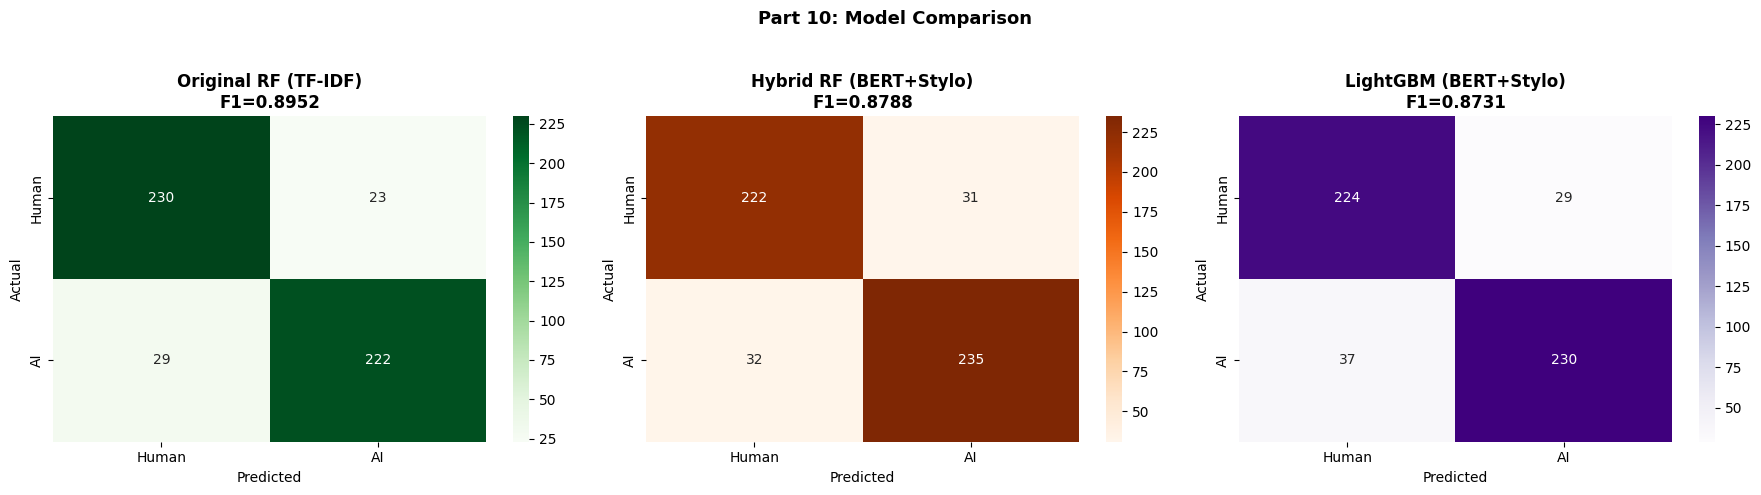

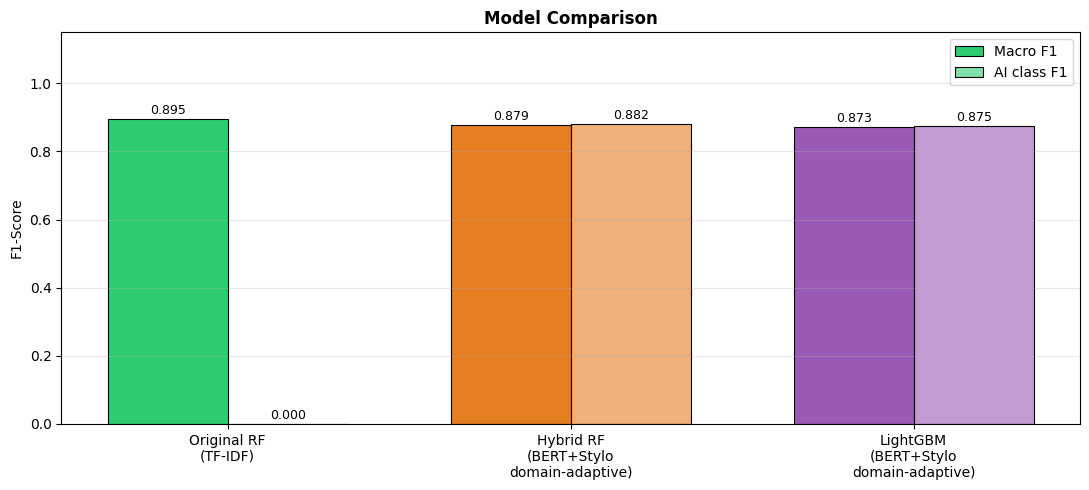

Best val model: Hybrid RF


In [ ]:
# PART 10c: VISUALISE MODEL COMPARISON

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs = [
    (ultimate_best["Predictions"], y_test_sr, f"Original RF (TF-IDF)\nF1={f1_orig:.4f}", "Greens"),
    (y_pred_rf, y_te, f"Hybrid RF (BERT+Stylo)\nF1={f1_hybrid_val:.4f}", "Oranges"),
    (y_pred_lgbm, y_te, f"LightGBM (BERT+Stylo)\nF1={f1_lgbm_val:.4f}", "Purples"),
]

for ax, (preds, ytrue, title, cmap) in zip(axes, configs):
    cm = confusion_matrix(ytrue, preds, labels=[0, 1])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap=cmap,
        xticklabels=["Human", "AI"], yticklabels=["Human", "AI"], ax=ax
    )
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Part 10: Model Comparison", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# F1 bar chart
fig, ax = plt.subplots(figsize=(11, 5))
names = [
    "Original RF\n(TF-IDF)",
    "Hybrid RF\n(BERT+Stylo\ndomain-adaptive)",
    "LightGBM\n(BERT+Stylo\ndomain-adaptive)"
]
f1s = [f1_orig, f1_hybrid_val, f1_lgbm_val]
ai_f1s = [0.0, f1_hybrid_ai_val, f1_lgbm_ai_val]
colors = ["#2ecc71", "#e67e22", "#9b59b6"]

x = np.arange(len(names))
w = 0.35
b1 = ax.bar(x - w/2, f1s, w, label="Macro F1", color=colors, edgecolor="black", linewidth=0.8)
b2 = ax.bar(
    x + w/2, ai_f1s, w, label="AI class F1",
    color=[c + "99" for c in ["#2ecc71", "#e67e22", "#9b59b6"]],
    edgecolor="black", linewidth=0.8
)

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.005, f"{h:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel("F1-Score")
ax.set_ylim(0, 1.15)
ax.set_title("Model Comparison", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best val model: {deploy_name}")


In [ ]:
# PART 11b: EVALUATE ON REAL GPT-4o-mini OUTPUT
from sklearn.metrics import f1_score, classification_report
import numpy as np
import pandas as pd
import time

def _safe_ai_f1(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if len(np.unique(y_true)) < 2:
        return 0.0
    vals = f1_score(y_true, y_pred, average=None, zero_division=0)
    return float(vals[1]) if len(vals) > 1 else 0.0

def build_classical_features(df_eval):
    df_e = df_eval.copy()

    if "content_type" not in df_e.columns:
        df_e["content_type"] = "article"

    intrinsic_cols = [
        "word_count","character_count","sentence_count","lexical_diversity",
        "avg_sentence_length","avg_word_length","punctuation_ratio",
        "flesch_reading_ease","gunning_fog_index","grammar_errors",
        "passive_voice_ratio","predictability_score","burstiness","sentiment_score"
    ]
    for col in intrinsic_cols:
        if col not in df_e.columns:
            df_e[col] = 0.0

    X_num = df_e[intrinsic_cols].fillna(0)
    adv_df = pd.DataFrame(list(df_e["text_content"].astype(str).apply(extract_advanced_features)))

    if "content_type" in augmented_df_sr.columns:
        ct_cols = pd.get_dummies(augmented_df_sr["content_type"], prefix="content", drop_first=True).columns.tolist()
    else:
        ct_cols = []
    ct_dum = pd.get_dummies(df_e["content_type"], prefix="content", drop_first=False)
    for col in ct_cols:
        if col not in ct_dum.columns:
            ct_dum[col] = 0
    ct_dum = ct_dum[ct_cols] if ct_cols else pd.DataFrame(index=df_e.index)

    X_tf = tfidf_temp.transform(df_e["text_content"].astype(str)).toarray()
    X_ch = char_temp.transform(df_e["text_content"].astype(str)).toarray()

    X_all = np.hstack([X_num.values, adv_df.values, ct_dum.values, X_tf, X_ch])
    X_sel = selector_temp.transform(np.abs(X_all))
    return X_sel

if "df_real_eval" not in globals() or len(df_real_eval) == 0:
    raise ValueError("df_real_eval is missing/empty. Run your GPT sample generation cell first.")

y_eval = df_real_eval["label"].values
X_classical_eval = build_classical_features(df_real_eval)
eval_texts_list = df_real_eval["text_content"].astype(str).tolist()

# 1) Original TF-IDF RF
y_pred_orig = ultimate_best["Model"].predict(X_classical_eval)
f1_orig_real = f1_score(y_eval, y_pred_orig, average="macro", zero_division=0)
f1_orig_ai_real = _safe_ai_f1(y_eval, y_pred_orig)

# 2) Hybrid features for eval
print("Extracting frozen BERT embeddings for eval set...")
t0 = time.time()
X_bert_eval = get_bert_embeddings(eval_texts_list)
print(f"Done in {(time.time()-t0):.0f}s. Shape: {X_bert_eval.shape}")

X_stylo_eval = X_classical_eval[:, top_stylometric_indices]
X_hybrid_eval = np.hstack([X_bert_eval, X_stylo_eval])

# Optional guard
if hasattr(rf_hybrid, "n_features_in_") and X_hybrid_eval.shape[1] != rf_hybrid.n_features_in_:
    raise ValueError(f"Hybrid eval shape mismatch: {X_hybrid_eval.shape[1]} vs rf_hybrid expects {rf_hybrid.n_features_in_}")

# 3) Hybrid RF
y_pred_rf_eval = rf_hybrid.predict(X_hybrid_eval)
f1_rf_real = f1_score(y_eval, y_pred_rf_eval, average="macro", zero_division=0)
f1_rf_ai_real = _safe_ai_f1(y_eval, y_pred_rf_eval)

# 4) LightGBM
y_pred_lgbm_eval = lgbm_model.predict(X_hybrid_eval)
f1_lgbm_real = f1_score(y_eval, y_pred_lgbm_eval, average="macro", zero_division=0)
f1_lgbm_ai_real = _safe_ai_f1(y_eval, y_pred_lgbm_eval)

# Deploy model eval
y_pred_ft = deploy_predict(X_hybrid_eval)
f1_ft_real = f1_score(y_eval, y_pred_ft, average="macro", zero_division=0)
f1_ft_ai_real = _safe_ai_f1(y_eval, y_pred_ft)

df_real_eval["pred_orig"] = y_pred_orig
df_real_eval["pred_hybrid"] = y_pred_rf_eval
df_real_eval["pred_lgbm"] = y_pred_lgbm_eval
df_real_eval["pred_ft"] = y_pred_ft
df_real_eval["correct_orig"] = (y_eval == y_pred_orig)
df_real_eval["correct_hybrid"] = (y_eval == y_pred_rf_eval)
df_real_eval["correct_ft"] = (y_eval == y_pred_ft)

print("\n" + "=" * 72)
print("PART 11: GENERALISATION TO REAL GPT-4o-mini OUTPUT")
print("=" * 72)
print(f"{'Model':<40} {'In-Dist':>8} {'Real F1':>8} {'Gap':>8} {'AI F1':>8}")
print("-" * 72)
print(f"{'Original RF (TF-IDF)':<40} {ultimate_best['F1-Score']:>8.4f} {f1_orig_real:>8.4f} {f1_orig_real-ultimate_best['F1-Score']:>+8.4f} {f1_orig_ai_real:>8.4f}")
print(f"{'Hybrid RF (BERT+Stylo, domain-adaptive)':<40} {f1_hybrid_val:>8.4f} {f1_rf_real:>8.4f} {f1_rf_real-f1_hybrid_val:>+8.4f} {f1_rf_ai_real:>8.4f}")
print(f"{'LightGBM (BERT+Stylo, domain-adaptive)':<40} {f1_lgbm_val:>8.4f} {f1_lgbm_real:>8.4f} {f1_lgbm_real-f1_lgbm_val:>+8.4f} {f1_lgbm_ai_real:>8.4f}")
print("=" * 72)

print(f"\nDeployment model ({deploy_name}) report on real GPT output:")
print(classification_report(y_eval, y_pred_ft, target_names=["Human", "AI"]))

print("\nPer-source performance:")
for src in df_real_eval["source"].unique():
    m = df_real_eval["source"] == src
    src_f1 = f1_score(df_real_eval.loc[m, "label"], df_real_eval.loc[m, "pred_ft"], average="macro", zero_division=0)
    src_labels = df_real_eval.loc[m, "label"].unique()
    if len(src_labels) > 1:
        src_ai = _safe_ai_f1(df_real_eval.loc[m, "label"], df_real_eval.loc[m, "pred_ft"])
        ai_str = f"{src_ai:.3f}"
    else:
        ai_str = "n/a"
    print(f"  {src:<15s} macro F1={src_f1:.3f} AI F1={ai_str} (n={m.sum()})")


Extracting frozen BERT embeddings for eval set...
  Embedded 32/150
Done in 3s. Shape: (150, 768)

PART 11: GENERALISATION TO REAL GPT-4o-mini OUTPUT
Model                                     In-Dist  Real F1      Gap    AI F1
------------------------------------------------------------------------
Original RF (TF-IDF)                       0.8952   0.3182  -0.5770   0.0000
Hybrid RF (BERT+Stylo, domain-adaptive)    0.8788   0.9866  +0.1078   0.9877
LightGBM (BERT+Stylo, domain-adaptive)     0.8731   0.9933  +0.1202   0.9938

Deployment model (Hybrid RF) report on real GPT output:
              precision    recall  f1-score   support

       Human       1.00      0.97      0.99        70
          AI       0.98      1.00      0.99        80

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150


Per-source performance:
  gpt-4o-mini     macro F1=1.000 AI F1=n/a (n=80)
  human   

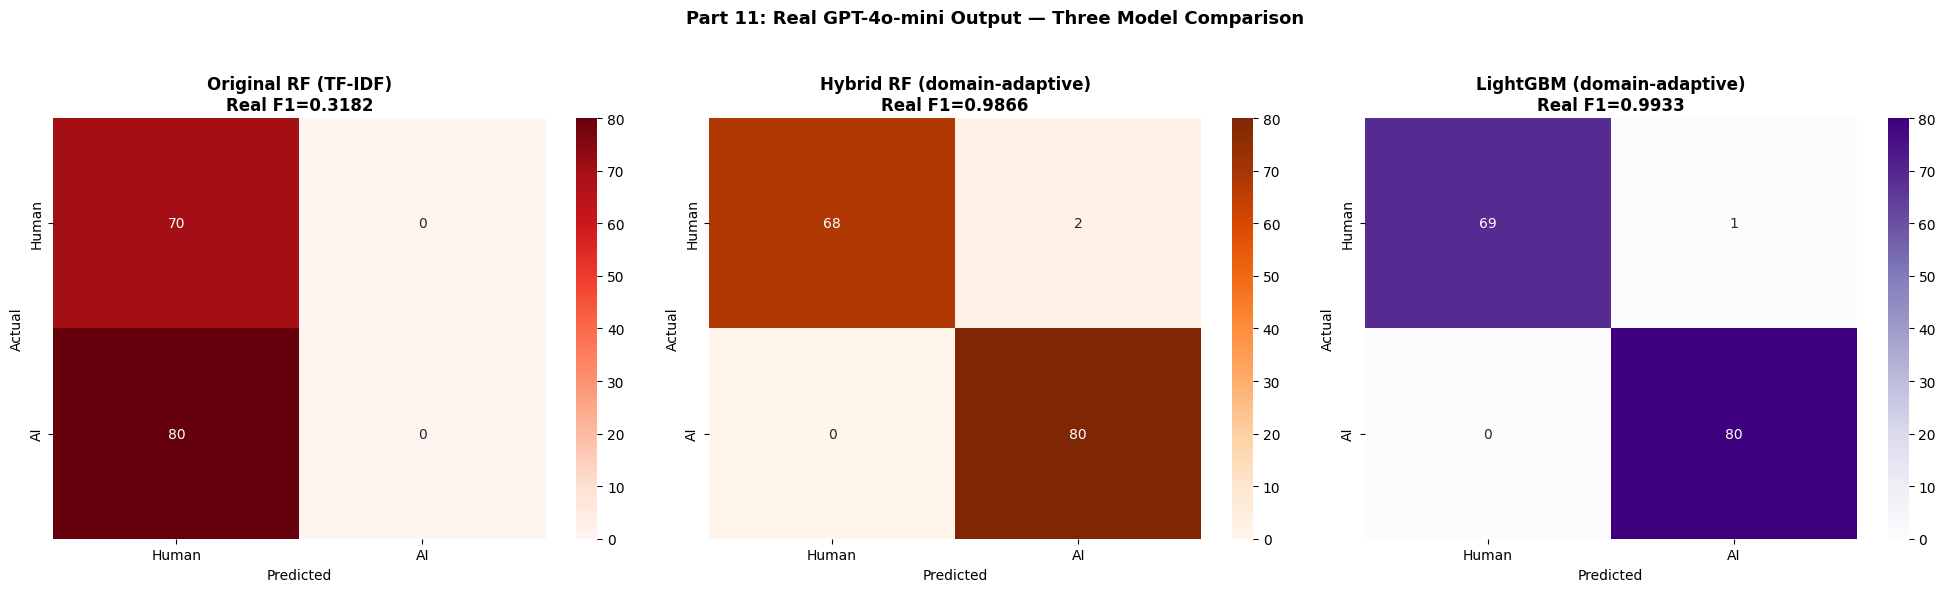

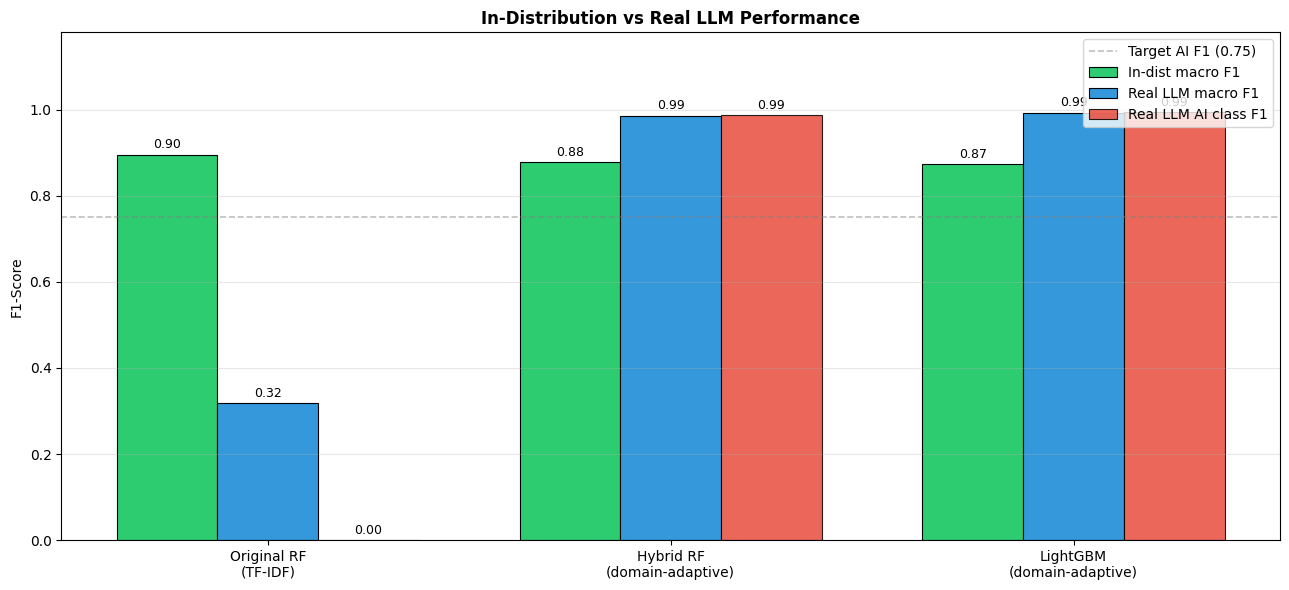

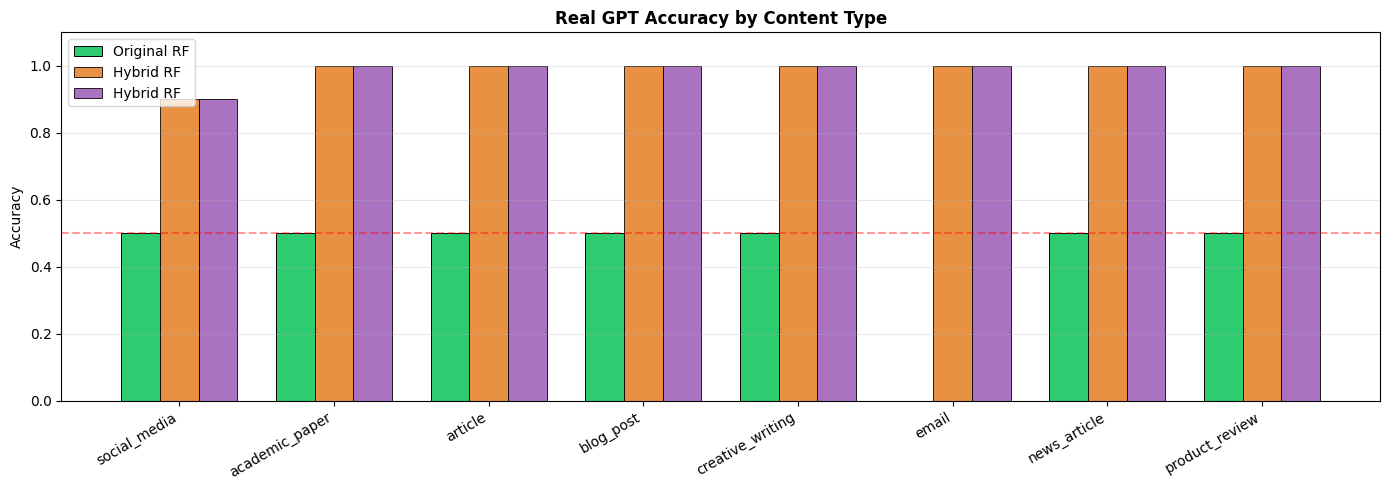

DEPLOYMENT DECISION
Hybrid RF meets target (AI F1=0.994 >= 0.75)
DEPLOY: Hybrid RF


In [ ]:
# PART 11c: VISUALISE GENERALISATION RESULTS
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
model_results = [
    (y_pred_orig,      f"Original RF (TF-IDF)\nReal F1={f1_orig_real:.4f}", "Reds"),
    (y_pred_rf_eval,   f"Hybrid RF (domain-adaptive)\nReal F1={f1_rf_real:.4f}", "Oranges"),
    (y_pred_lgbm_eval, f"LightGBM (domain-adaptive)\nReal F1={f1_lgbm_real:.4f}", "Purples"),
]

for ax, (preds, title, cmap) in zip(axes, model_results):
    cm = confusion_matrix(y_eval, preds, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                xticklabels=["Human","AI"], yticklabels=["Human","AI"], ax=ax)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Part 11: Real GPT-4o-mini Output — Three Model Comparison", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fig, ax = plt.subplots(figsize=(13, 6))
models = ["Original RF\n(TF-IDF)", "Hybrid RF\n(domain-adaptive)", "LightGBM\n(domain-adaptive)"]
in_dist_f1s = [ultimate_best["F1-Score"], f1_hybrid_val, f1_lgbm_val]
real_f1s = [f1_orig_real, f1_rf_real, f1_lgbm_real]
real_ai_f1s = [f1_orig_ai_real, f1_rf_ai_real, f1_lgbm_ai_real]

x = np.arange(len(models)); w = 0.25
b1 = ax.bar(x-w, in_dist_f1s, w, label="In-dist macro F1", color="#2ecc71", edgecolor="black", linewidth=0.8)
b2 = ax.bar(x,   real_f1s,    w, label="Real LLM macro F1", color="#3498db", edgecolor="black", linewidth=0.8)
b3 = ax.bar(x+w, real_ai_f1s, w, label="Real LLM AI class F1", color="#e74c3c", edgecolor="black", linewidth=0.8, alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.008, f"{h:.2f}", ha="center", va="bottom", fontsize=9)

ax.axhline(0.75, linestyle="--", color="gray", alpha=0.5, linewidth=1.2, label="Target AI F1 (0.75)")
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylabel("F1-Score"); ax.set_ylim(0, 1.18)
ax.set_title("In-Distribution vs Real LLM Performance", fontweight="bold")
ax.legend(loc="upper right"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
ct_acc = df_real_eval.groupby("content_type")[["correct_orig","correct_hybrid","correct_ft"]].mean().sort_values("correct_ft")
x = np.arange(len(ct_acc)); w = 0.25
ax.bar(x-w, ct_acc["correct_orig"],   w, label="Original RF", color="#2ecc71", edgecolor="black", linewidth=0.7)
ax.bar(x,   ct_acc["correct_hybrid"], w, label="Hybrid RF",   color="#e67e22", edgecolor="black", linewidth=0.7, alpha=0.85)
ax.bar(x+w, ct_acc["correct_ft"],     w, label=deploy_name,   color="#9b59b6", edgecolor="black", linewidth=0.7, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(ct_acc.index, rotation=30, ha="right")
ax.set_ylabel("Accuracy"); ax.legend()
ax.set_title("Real GPT Accuracy by Content Type", fontweight="bold")
ax.set_ylim(0, 1.1); ax.axhline(0.5, linestyle="--", alpha=0.4, color="red")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("="*70)
print("DEPLOYMENT DECISION")
print("="*70)
best_ai = max(f1_rf_ai_real, f1_lgbm_ai_real)
if best_ai >= 0.75:
    print(f"{deploy_name} meets target (AI F1={best_ai:.3f} >= 0.75)")
    print(f"DEPLOY: {deploy_name}")
elif best_ai >= 0.55:
    print(f"{deploy_name} partially meets target (AI F1={best_ai:.3f})")
    print(f"DEPLOY: {deploy_name} with documented limitations")
else:
    print(f"Both models below target. Best AI F1={best_ai:.3f}")
    print("Recommendation: increase GPT training samples (N_PER_TYPE=20) and re-run.")
print("="*70)


In [ ]:
import os
import joblib
import torch
from datetime import datetime

save_dir = "models"
os.makedirs(save_dir, exist_ok=True)

torch.save(bert_model.state_dict(), os.path.join(save_dir, "avh_bert.pt"))

model_bundle = {
    "model": deploy_model,
    "model_name": deploy_name,
    "tfidf": tfidf_temp,
    "char": char_temp,
    "selector": selector_temp,
    "top_stylometric_indices": top_stylometric_indices,
    "expected_features": int(deploy_model.n_features_in_),
    "bert_model_name": "distilbert-base-uncased",
    "saved_at": datetime.now().isoformat(),
}

joblib.dump(model_bundle, os.path.join(save_dir, "avh_best_bundle.pkl"))

print(f"Saved best model bundle: {os.path.join(save_dir, 'avh_best_bundle.pkl')}")
print(f"Model: {deploy_name} | expected_features={model_bundle['expected_features']}")


Saved best model bundle: models/avh_best_bundle.pkl
Model: Hybrid RF | expected_features=788


  Embedded 32/150
Best model: Hybrid RF
Accuracy: 0.987
              precision    recall  f1-score   support

       Human       1.00      0.97      0.99        70
          AI       0.98      1.00      0.99        80

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150


Error breakdown:
error_type
Correct                         148
False Positive (Human -> AI)      2
Name: count, dtype: int64


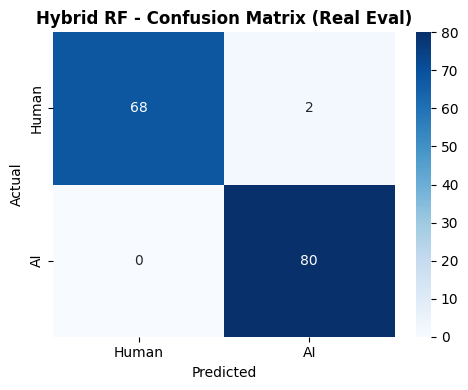

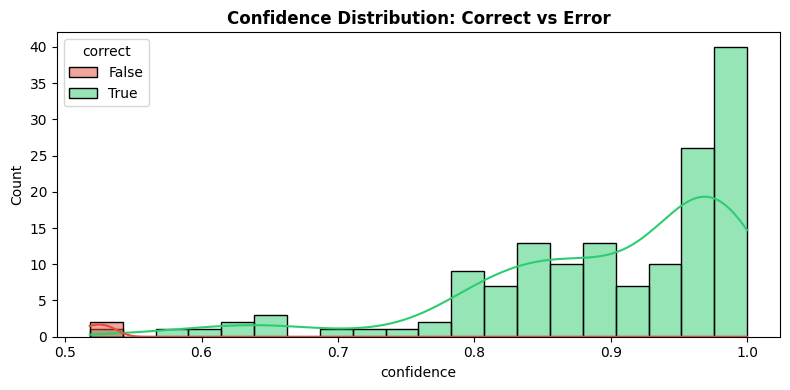

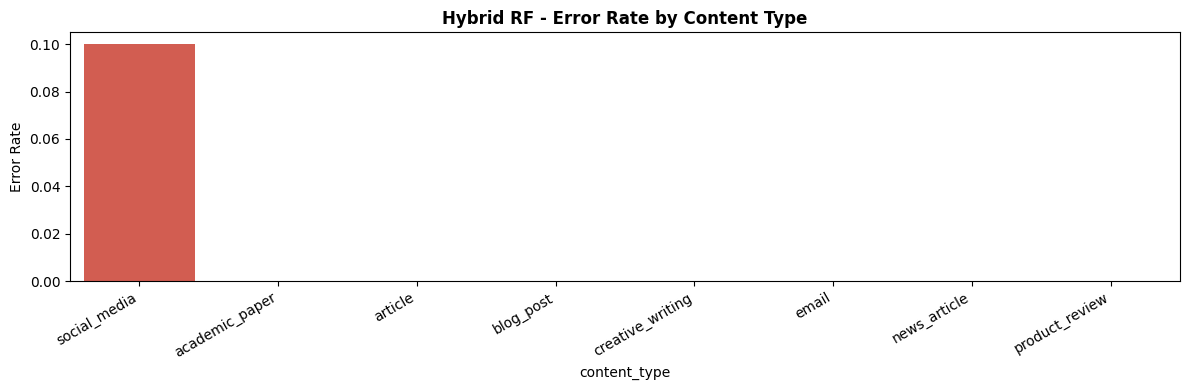


Top high-confidence errors:


,text_content,content_type,error_type,confidence,y_true,y_pred
122,Foreign campaign box direction material. Ago e...,social_media,False Positive (Human -> AI),0.531389,0,1
121,Physical thousand face issue people record com...,social_media,False Positive (Human -> AI),0.518000,0,1


In [ ]:
# PART 12a: ERROR ANALYSIS FOR BEST DEPLOY MODEL

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

if "deploy_model" not in globals():
    raise ValueError("deploy_model not found. Run Part 10b first.")
if "df_real_eval" not in globals() or len(df_real_eval) == 0:
    raise ValueError("df_real_eval not found/empty. Run the GPT generation cell first.")

X_classical_eval = build_classical_features(df_real_eval)
X_stylo_eval = X_classical_eval[:, top_stylometric_indices]
X_bert_eval = get_bert_embeddings(df_real_eval["text_content"].astype(str).tolist())
X_hybrid_eval = np.hstack([X_bert_eval, X_stylo_eval])

if hasattr(deploy_model, "n_features_in_") and X_hybrid_eval.shape[1] != deploy_model.n_features_in_:
    raise ValueError(f"Feature mismatch: X has {X_hybrid_eval.shape[1]}, model expects {deploy_model.n_features_in_}")

y_true = df_real_eval["label"].values
y_pred = deploy_model.predict(X_hybrid_eval)

if hasattr(deploy_model, "predict_proba"):
    probs = deploy_model.predict_proba(X_hybrid_eval)
    conf = probs.max(axis=1)
    p_ai = probs[:, 1]
else:
    dec = deploy_model.decision_function(X_hybrid_eval)
    dec = np.asarray(dec)
    conf = np.abs(dec) / (np.max(np.abs(dec)) if np.max(np.abs(dec)) != 0 else 1.0)
    p_ai = np.full_like(conf, np.nan, dtype=float)

ea = df_real_eval.copy()
ea["y_true"] = y_true
ea["y_pred"] = y_pred
ea["correct"] = (y_true == y_pred)
ea["confidence"] = conf
ea["p_ai"] = p_ai
ea["text_length"] = ea["text_content"].astype(str).str.len()

def err_type(r):
    if r["correct"]:
        return "Correct"
    if r["y_true"] == 0 and r["y_pred"] == 1:
        return "False Positive (Human -> AI)"
    return "False Negative (AI -> Human)"

ea["error_type"] = ea.apply(err_type, axis=1)

print(f"Best model: {deploy_name}")
print(f"Accuracy: {ea['correct'].mean():.3f}")
print(classification_report(y_true, y_pred, target_names=["Human", "AI"], zero_division=0))
print("\nError breakdown:")
print(ea["error_type"].value_counts())

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Human", "AI"], yticklabels=["Human", "AI"])
plt.title(f"{deploy_name} - Confusion Matrix (Real Eval)", fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(data=ea, x="confidence", hue="correct", bins=20, kde=True,
             palette={True: "#2ecc71", False: "#e74c3c"})
plt.title("Confidence Distribution: Correct vs Error", fontweight="bold")
plt.tight_layout()
plt.show()

if "content_type" in ea.columns:
    ct = ea.groupby("content_type")["correct"].agg(["sum", "count"])
    ct["error_rate"] = 1 - (ct["sum"] / ct["count"])
    ct = ct.sort_values("error_rate", ascending=False)
    plt.figure(figsize=(12, 4))
    sns.barplot(x=ct.index, y=ct["error_rate"], color="#e74c3c")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Error Rate")
    plt.title(f"{deploy_name} - Error Rate by Content Type", fontweight="bold")
    plt.tight_layout()
    plt.show()

print("\nTop high-confidence errors:")
show_cols = ["text_content", "content_type", "error_type", "confidence", "y_true", "y_pred"]
show_cols = [c for c in show_cols if c in ea.columns]
top_err = ea[~ea["correct"]].sort_values("confidence", ascending=False).head(10)[show_cols]
display(top_err)



PASS 1 - Correct AI (High Confidence)
True: AI | Pred: AI | Conf: 1.000
Text: I recently purchased a pair of wireless noise-cancelling headphones, and they have significantly enhanced my listening experience. One of the standout features is the impressive noise cancellation technology, which effectively blocks out background sounds, making them perfect for...
  Embedded 32/500
  Embedded 352/500


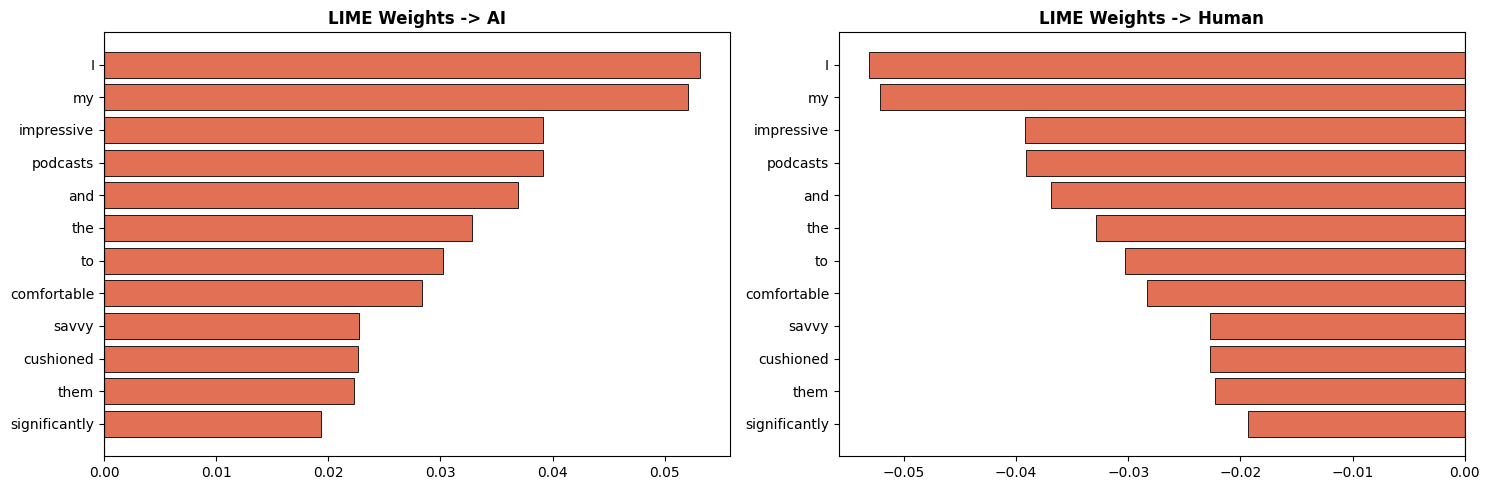


PASS 2 - Correct Human (High Confidence)
True: Human | Pred: Human | Conf: 0.921
Text: Place increase white thank raise among. Responsibility debate stop wait fire adult. Create region recent TV month trade stay agent.
Development production report Mr state. Instead talk other read believe these every.
Style happy great. Car line tonight create voice....
  Embedded 32/500
  Embedded 352/500


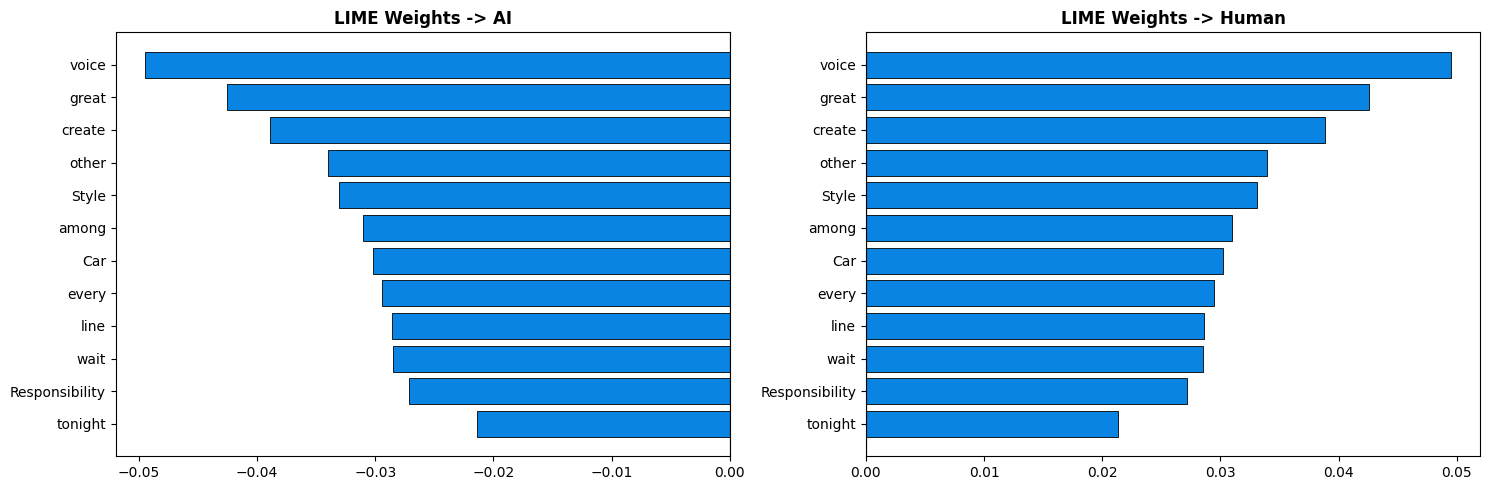

In [ ]:
# PART 12b: LIME EXPLANATIONS FOR BEST DEPLOY MODEL

import lime
import lime.lime_text
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def predict_proba_text_best(texts):
    texts = [str(t) for t in texts]
    df_tmp = pd.DataFrame({
        "text_content": texts,
        "content_type": ["article"] * len(texts)
    })
    X_class = build_classical_features(df_tmp)
    X_stylo = X_class[:, top_stylometric_indices]
    X_bert = get_bert_embeddings(texts)
    X_hybrid = np.hstack([X_bert, X_stylo])

    if hasattr(deploy_model, "n_features_in_") and X_hybrid.shape[1] != deploy_model.n_features_in_:
        raise ValueError(f"LIME feature mismatch: {X_hybrid.shape[1]} vs {deploy_model.n_features_in_}")

    if hasattr(deploy_model, "predict_proba"):
        return deploy_model.predict_proba(X_hybrid)

    d = deploy_model.decision_function(X_hybrid)
    d = np.asarray(d).reshape(-1)
    p1 = 1 / (1 + np.exp(-d))
    return np.vstack([1 - p1, p1]).T

explainer_lime = lime.lime_text.LimeTextExplainer(class_names=["Human", "AI"], random_state=42)
label_map = {0: "Human", 1: "AI"}

if "ea" not in globals():
    X_classical_eval = build_classical_features(df_real_eval)
    X_stylo_eval = X_classical_eval[:, top_stylometric_indices]
    X_bert_eval = get_bert_embeddings(df_real_eval["text_content"].astype(str).tolist())
    X_hybrid_eval = np.hstack([X_bert_eval, X_stylo_eval])
    y_pred = deploy_model.predict(X_hybrid_eval)
    probs = deploy_model.predict_proba(X_hybrid_eval) if hasattr(deploy_model, "predict_proba") else np.full((len(df_real_eval), 2), 0.5)
    ea = df_real_eval.copy()
    ea["y_true"] = df_real_eval["label"].values
    ea["y_pred"] = y_pred
    ea["correct"] = ea["y_true"] == ea["y_pred"]
    ea["confidence"] = probs.max(axis=1)

def run_lime_case(row, title, num_features=12):
    text = str(row["text_content"])
    true_label = int(row["y_true"])
    pred_label = int(row["y_pred"])
    conf = float(row["confidence"])

    print(f"\n{'='*70}")
    print(title)
    print(f"True: {label_map[true_label]} | Pred: {label_map[pred_label]} | Conf: {conf:.3f}")
    print(f"{'='*70}")
    print(f"Text: {text[:280]}...")

    exp = explainer_lime.explain_instance(
        text,
        predict_proba_text_best,
        num_features=num_features,
        num_samples=500,
        labels=[0, 1]
    )

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for class_idx, ax, cname, pos, neg in [
        (1, axes[0], "AI", "#e17055", "#0984e3"),
        (0, axes[1], "Human", "#0984e3", "#e17055"),
    ]:
        ww = exp.as_list(label=class_idx)
        words = [w for w, _ in ww]
        vals = [v for _, v in ww]
        colors = [pos if v > 0 else neg for v in vals]
        ax.barh(words[::-1], vals[::-1], color=colors[::-1], edgecolor="black", linewidth=0.6)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title(f"LIME Weights -> {cname}", fontweight="bold")
    plt.tight_layout()
    plt.show()
    return exp

cases = []

c1 = ea[(ea["correct"]) & (ea["y_true"] == 1)].sort_values("confidence", ascending=False).head(1)
if len(c1): cases.append(("PASS 1 - Correct AI (High Confidence)", c1.iloc[0]))

c2 = ea[(ea["correct"]) & (ea["y_true"] == 0)].sort_values("confidence", ascending=False).head(1)
if len(c2): cases.append(("PASS 2 - Correct Human (High Confidence)", c2.iloc[0]))

fn = ea[(~ea["correct"]) & (ea["y_true"] == 1)].sort_values("confidence", ascending=False).head(2)
for i in range(len(fn)):
    cases.append((f"PASS {3+i} - False Negative #{i+1} (AI -> Human)", fn.iloc[i]))

if len(cases) == 0:
    print("No eligible rows found for LIME passes.")
else:
    lime_explanations = []
    for title, row in cases:
        exp = run_lime_case(row, title)
        lime_explanations.append((title, exp))


In [ ]:
# PART 13: LOW-FP UPGRADE (Leak-safe split + real-human threshold tuning)

import os
import re
import random
import numpy as np
import pandas as pd
import joblib
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.calibration import CalibratedClassifierCV

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

SLANG_MAP = {
    "you": "u", "your": "ur", "are": "r", "to": "2", "for": "4",
    "because": "cuz", "please": "pls", "people": "ppl","really":"rlly", "i do not know": "idk", "laughing":"lmao","me":"meee","the": "theee", "great": "gr8"
}

def inject_typos(text, prob=0.02):
    chars = list(text)
    out = []
    for ch in chars:
        if ch.isalpha() and random.random() < prob:
            r = random.random()
            if r < 0.33:
                continue
            elif r < 0.66:
                out.append(ch)
                out.append(ch)
            else:
                out.append(ch.swapcase())
        else:
            out.append(ch)
    return "".join(out)

def to_casual_style(text):
    toks = text.split()
    out = []
    for t in toks:
        key = re.sub(r"[^a-zA-Z]", "", t).lower()
        out.append(SLANG_MAP.get(key, t))
    s = " ".join(out)
    s = re.sub(r"\bI am\b", "I'm", s)
    s = re.sub(r"\bdo not\b", "don't", s, flags=re.I)
    s = re.sub(r"\bcannot\b", "can't", s, flags=re.I)
    return s

def shorten_text(text, keep_ratio=0.5):
    words = text.split()
    if len(words) < 20:
        return text
    k = max(8, int(len(words) * keep_ratio))
    return " ".join(words[:k])

def diversify_human_text(text):
    return [
        inject_typos(text, prob=0.02),
        to_casual_style(text),
        shorten_text(text, keep_ratio=0.5),
    ]

if "all_texts" in globals() and "all_labels" in globals() and "all_ct" in globals():
    base_df = pd.DataFrame({
        "text_content": [str(t) for t in all_texts],
        "label": list(map(int, all_labels)),
        "content_type": [str(c) for c in all_ct],
    })
else:
    base_df = augmented_df_sr[["text_content", "label", "content_type"]].copy()
    if "df_real_eval" in globals() and len(df_real_eval):
        tmp = df_real_eval.copy()
        for col in ["text_content", "label", "content_type"]:
            if col not in tmp.columns:
                tmp[col] = "article" if col == "content_type" else 0
        base_df = pd.concat([base_df, tmp[["text_content", "label", "content_type"]]], ignore_index=True)

# optional extra real human corpus
extra_human_path = "real_human_extra.csv"
if os.path.exists(extra_human_path):
    extra_human = pd.read_csv(extra_human_path)
    if "text_content" in extra_human.columns:
        extra_human["label"] = 0
        if "content_type" not in extra_human.columns:
            extra_human["content_type"] = "article"
        base_df = pd.concat(
            [base_df, extra_human[["text_content", "label", "content_type"]]],
            ignore_index=True
        )
        print(f"Loaded external human corpus: {len(extra_human):,} rows")

# de-dup first
base_df["text_content"] = base_df["text_content"].astype(str).str.strip()
base_df = base_df.drop_duplicates(subset=["text_content", "label"]).reset_index(drop=True)
print(f"Base pool (dedup): {len(base_df):,}")

train_base, val_base = train_test_split(
    base_df, test_size=0.2, random_state=RANDOM_STATE, stratify=base_df["label"]
)

# Augment only train human samples
human_train = train_base[train_base["label"] == 0].copy()
aug_rows = []
for _, row in human_train.iterrows():
    txt = str(row["text_content"])
    for v in diversify_human_text(txt):
        aug_rows.append({
            "text_content": v,
            "label": 0,
            "content_type": row.get("content_type", "article")
        })

human_aug_df = pd.DataFrame(aug_rows)
train_df_v2 = pd.concat([train_base, human_aug_df], ignore_index=True)
train_df_v2 = train_df_v2.drop_duplicates(subset=["text_content", "label"]).reset_index(drop=True)
val_df_v2 = val_base.copy()

print(f"Train base: {len(train_base):,}")
print(f"Human aug added: {len(human_aug_df):,}")
print(f"Train final: {len(train_df_v2):,}")
print(f"Val final: {len(val_df_v2):,}")

def build_classical_from_df(df_in):
    df_e = df_in.copy()
    if "content_type" not in df_e.columns:
        df_e["content_type"] = "article"

    intrinsic_cols = [
        "word_count","character_count","sentence_count","lexical_diversity",
        "avg_sentence_length","avg_word_length","punctuation_ratio",
        "flesch_reading_ease","gunning_fog_index","grammar_errors",
        "passive_voice_ratio","predictability_score","burstiness","sentiment_score"
    ]

    intr_df = pd.DataFrame(list(df_e["text_content"].astype(str).apply(calculate_intrinsic_features)))
    for c in intrinsic_cols:
        df_e[c] = intr_df.get(c, 0)
        df_e[c] = df_e[c].fillna(0)

    X_num = df_e[intrinsic_cols].values
    adv_df = pd.DataFrame(list(df_e["text_content"].astype(str).apply(extract_advanced_features)))

    if "content_type" in augmented_df_sr.columns:
        ct_cols = pd.get_dummies(
            augmented_df_sr["content_type"], prefix="content", drop_first=True
        ).columns.tolist()
    else:
        ct_cols = []

    ct_dum = pd.get_dummies(df_e["content_type"], prefix="content", drop_first=False)
    for c in ct_cols:
        if c not in ct_dum.columns:
            ct_dum[c] = 0
    ct_dum = ct_dum[ct_cols] if ct_cols else pd.DataFrame(index=df_e.index)

    X_tf = tfidf_temp.transform(df_e["text_content"].astype(str)).toarray()
    X_ch = char_temp.transform(df_e["text_content"].astype(str)).toarray()

    X_all = np.hstack([X_num, adv_df.values, ct_dum.values, X_tf, X_ch])
    return selector_temp.transform(np.abs(X_all))

# train/val matrices
X_bert_tr = get_bert_embeddings(train_df_v2["text_content"].astype(str).tolist())
X_cls_tr = build_classical_from_df(train_df_v2)

X_bert_va = get_bert_embeddings(val_df_v2["text_content"].astype(str).tolist())
X_cls_va = build_classical_from_df(val_df_v2)

if "top_stylometric_indices" in globals() and len(top_stylometric_indices):
    sty_idx = np.array(top_stylometric_indices)
else:
    sty_idx = np.arange(min(20, X_cls_tr.shape[1]))

X_tr = np.hstack([X_bert_tr, X_cls_tr[:, sty_idx]])
X_va = np.hstack([X_bert_va, X_cls_va[:, sty_idx]])

y_tr = train_df_v2["label"].astype(int).values
y_va = val_df_v2["label"].astype(int).values

print("Hybrid train shape:", X_tr.shape)
print("Hybrid val shape:", X_va.shape)

base_lgbm_v2 = lgb.LGBMClassifier(
    n_estimators=600,
    learning_rate=0.04,
    num_leaves=63,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.15,
    reg_lambda=0.15,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

cal_lgbm_v2 = CalibratedClassifierCV(
    estimator=base_lgbm_v2,
    method="sigmoid",
    cv=3
)
cal_lgbm_v2.fit(X_tr, y_tr)

p_ai_va = cal_lgbm_v2.predict_proba(X_va)[:, 1]

FP_TARGET = 0.05
thr_grid = np.arange(0.50, 0.96, 0.01)

best_thr = 0.80
best_f1 = -1.0

for thr in thr_grid:
    pred = (p_ai_va >= thr).astype(int)
    human_mask = (y_va == 0)
    fp_rate = pred[human_mask].mean() if human_mask.any() else 0.0
    if fp_rate <= FP_TARGET:
        f1m = f1_score(y_va, pred, average="macro", zero_division=0)
        if f1m > best_f1:
            best_f1 = f1m
            best_thr = float(np.round(thr, 2))

holdout_path = "real_human_holdout.csv"
if os.path.exists(holdout_path):
    hh = pd.read_csv(holdout_path)
    if "text_content" in hh.columns and len(hh) > 0:
        hh = hh.copy()
        hh["label"] = 0
        hh["content_type"] = hh.get("content_type", "article")
        Xh = np.hstack([
            get_bert_embeddings(hh["text_content"].astype(str).tolist()),
            build_classical_from_df(hh)[:, sty_idx]
        ])
        p_ai_h = cal_lgbm_v2.predict_proba(Xh)[:, 1]
        target_fp_holdout = 0.02
        valid = [t for t in thr_grid if (p_ai_h >= t).mean() <= target_fp_holdout]
        if valid:
            best_thr = float(np.round(max(valid), 2))
            print(f"Threshold updated by real_human_holdout.csv: {best_thr:.2f} (FP<={target_fp_holdout:.2%})")

pred_050 = (p_ai_va >= 0.50).astype(int)
pred_best = (p_ai_va >= best_thr).astype(int)

print(f"Validation macro F1 @0.50: {f1_score(y_va, pred_050, average='macro', zero_division=0):.4f}")
print(f"Validation macro F1 @{best_thr:.2f}: {f1_score(y_va, pred_best, average='macro', zero_division=0):.4f}")
print(f"Selected threshold: {best_thr:.2f} (FP target <= {FP_TARGET:.2%})")
print(classification_report(y_va, pred_best, target_names=["Human", "AI"], zero_division=0))
print("Confusion matrix @best threshold:")
print(confusion_matrix(y_va, pred_best))


save_dir = "models"
os.makedirs(save_dir, exist_ok=True)

bundle_v2 = {
    "model": cal_lgbm_v2,
    "model_name": "Calibrated LightGBM (v2)",
    "tfidf": tfidf_temp,
    "char": char_temp,
    "selector": selector_temp,
    "top_stylometric_indices": np.array(sty_idx),
    "expected_features": int(X_tr.shape[1]),
    "bert_model_name": "distilbert-base-uncased",
    "recommended_threshold": float(best_thr),
    "fp_target": float(FP_TARGET),
}

out_path = os.path.join(save_dir, "avh_best_bundle_v2.pkl")
joblib.dump(bundle_v2, out_path)
print(f"Saved: {out_path}")
print("Use this bundle in Streamlit.")


Base pool (dedup): 2,599
Train base: 2,079
Human aug added: 3,036
Train final: 4,872
Val final: 520
  Embedded 32/4872
  Embedded 352/4872
  Embedded 672/4872
  Embedded 992/4872
  Embedded 1312/4872
  Embedded 1632/4872
  Embedded 1952/4872
  Embedded 2272/4872
  Embedded 2592/4872
  Embedded 2912/4872
  Embedded 3232/4872
  Embedded 3552/4872
  Embedded 3872/4872
  Embedded 4192/4872
  Embedded 4512/4872
  Embedded 4832/4872
  Embedded 32/520
  Embedded 352/520
Hybrid train shape: (4872, 788)
Hybrid val shape: (520, 788)
Validation macro F1 @0.50: 0.8709
Validation macro F1 @0.60: 0.8608
Selected threshold: 0.60 (FP target <= 5.00%)
              precision    recall  f1-score   support

       Human       0.80      0.96      0.87       253
          AI       0.95      0.77      0.85       267

    accuracy                           0.86       520
   macro avg       0.88      0.86      0.86       520
weighted avg       0.88      0.86      0.86       520

Confusion matrix @best thresho